# IdiomX: Neural Detection of Idiomatic Expressions Using Transformer Models

- **Author:** Ayman Ali Sharara  
- **Project:** IdiomX – Neural Understanding of English Idioms  
- **gitHub dataset** : https://github.com/aymanshar/idiomx-dataset
- **GitHub deep learning repository** : https://github.com/aymanshar/idiomx/n
- **Year:** 2026  

**Objective:** Binary classification of idiomatic vs. literal usage in context.  
**Input:** A sentence containing an idiom candidate.  
**Output:** Idiomatic (`1`) or literal (`0`).  
**Models:** Logistic Regression (TF-IDF baseline), RoBERTa, and DeBERTa-v3.
---
## License
This work is released under the MIT License.

---

## Citation
If you use this dataset, please cite the IdiomX research paper.

## Task 1: Idiom Detection — Overview

The goal of this task is to determine whether a given sentence contains an idiomatic expression or is used in a literal sense.

Formally, given an input sentence  
x = (w₁, w₂, …, wₙ), where each w represents a word in the sentence,  
the objective is to classify the sentence into one of two categories:
- Literal (0)
- Idiomatic (1)

This task is important for several real-world applications, including:
- Machine translation (correct interpretation of figurative language)
- Search engines (semantic understanding of queries)
- Chatbots and conversational AI
- Evaluation of large language models (LLMs)
- Language learning systems

The dataset used in this task is balanced and constructed with multiple examples per idiom, including both literal and idiomatic usages, ensuring fair and robust evaluation.

We compare a classical machine learning baseline (Logistic Regression) with a transformer-based model (RoBERTa) to evaluate the impact of contextual understanding on idiom detection.

## 1. Environment Setup and Reproducibility

This notebook evaluates idiom detection as a binary classification task, where the goal is to predict whether a sentence uses an idiom figuratively or literally.

To ensure reproducibility, we begin by:
- importing required libraries
- fixing random seeds
- defining project and artifact paths
- preparing directories for outputs, figures, tables, and saved models

This notebook is designed to be reproducible and publication-oriented. Data loading and splitting will be performed explicitly in later sections.

In [8]:
# [1.1] Environment setup and reproducibility

from pathlib import Path
import os
import random
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# Display options for cleaner inspection in notebook
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.precision", 4)

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print("Random seed:", SEED)

# -----------------------------
# Project paths
# -----------------------------
# Assumes notebook is inside the project repository
PROJECT_ROOT = Path("..").resolve()

DATA_DIR = PROJECT_ROOT / "data"
OUTPUTS_DIR = PROJECT_ROOT / "outputs" / "task1_idiom_detection"
FIGURES_DIR = OUTPUTS_DIR / "figures"
TABLES_DIR = OUTPUTS_DIR / "tables"
MODELS_DIR = PROJECT_ROOT / "deep_learning" / "models" / "task1_idiom_detection"

# Create output directories if missing
for folder in [OUTPUTS_DIR, FIGURES_DIR, TABLES_DIR, MODELS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT :", PROJECT_ROOT)
print("OUTPUTS_DIR  :", OUTPUTS_DIR)
print("FIGURES_DIR  :", FIGURES_DIR)
print("TABLES_DIR   :", TABLES_DIR)
print("MODELS_DIR   :", MODELS_DIR)

Random seed: 42
PROJECT_ROOT : C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX
OUTPUTS_DIR  : C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\outputs\task1_idiom_detection
FIGURES_DIR  : C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\outputs\task1_idiom_detection\figures
TABLES_DIR   : C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\outputs\task1_idiom_detection\tables
MODELS_DIR   : C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\models\task1_idiom_detection


## 2. Load Dataset

We load the IdiomX dataset directly from Hugging Face to ensure reproducibility and avoid dependence on locally pre-split files.

At this stage, we:
- load the full dataset
- inspect its schema
- verify that the fields required for idiom detection are present
- prepare a clean working dataframe for analysis and splitting

In [10]:
# [2.1] Load IdiomX from Hugging Face

from datasets import load_dataset

HF_DATASET_NAME = "aymansharara/idiomx"

dataset = load_dataset(HF_DATASET_NAME)

print(dataset)
print("\nAvailable splits:", list(dataset.keys()))

DatasetDict({
    train: Dataset({
        features: ['idiom', 'meaning_en', 'example', 'source', 'source_type', 'pos', 'tags', 'idiom_confidence', 'source_url', 'idiom_canonical', 'idiom_canonical_meaning', 'idiom_canonical_meaning_arabic', 'is_idiom', 'ambiguity_flag', 'idiom_compositionality_level', 'idiom_register', 'idiom_domain', 'learner_difficulty', 'idiom_surface', 'idiom_in_example', 'idiom_in_example_arabic', 'idiom_in_example_meaning_en', 'idiom_in_example_meaning_arabic', 'is_example_idiom', 'example_usage_label', 'is_generated_example', 'enrichment_model', 'enrichment_version', 'validation_status', 'example_length', 'idiom_present', 'contains_profanity', 'semantic_consistency', 'canonical_semantic_score'],
        num_rows: 123336
    })
})

Available splits: ['train']


In [11]:
# [2.2] Convert to pandas and inspect structure

# Prefer 'train' split if the dataset is published as a single main split
df = dataset["train"].to_pandas().copy()

print("Full dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head(3))

Full dataset shape: (123336, 34)

Columns:
['idiom', 'meaning_en', 'example', 'source', 'source_type', 'pos', 'tags', 'idiom_confidence', 'source_url', 'idiom_canonical', 'idiom_canonical_meaning', 'idiom_canonical_meaning_arabic', 'is_idiom', 'ambiguity_flag', 'idiom_compositionality_level', 'idiom_register', 'idiom_domain', 'learner_difficulty', 'idiom_surface', 'idiom_in_example', 'idiom_in_example_arabic', 'idiom_in_example_meaning_en', 'idiom_in_example_meaning_arabic', 'is_example_idiom', 'example_usage_label', 'is_generated_example', 'enrichment_model', 'enrichment_version', 'validation_status', 'example_length', 'idiom_present', 'contains_profanity', 'semantic_consistency', 'canonical_semantic_score']


,idiom,meaning_en,example,source,source_type,pos,tags,idiom_confidence,source_url,idiom_canonical,idiom_canonical_meaning,idiom_canonical_meaning_arabic,is_idiom,ambiguity_flag,idiom_compositionality_level,idiom_register,idiom_domain,learner_difficulty,idiom_surface,idiom_in_example,idiom_in_example_arabic,idiom_in_example_meaning_en,idiom_in_example_meaning_arabic,is_example_idiom,example_usage_label,is_generated_example,enrichment_model,enrichment_version,validation_status,example_length,idiom_present,contains_profanity,semantic_consistency,canonical_semantic_score
0,$100 hamburger,Used other than figuratively or idiomatically: see hamburger.,Daniel Boulud has a restaurant that serves a truffle and Kobe steak hamburger for $100 […] It's to make everything e...,kaikki_wiktionary,dictionary,noun,None,high,NaN,$100 hamburger,"In aviation and pilot culture, a ""$100 hamburger"" refers to a flight solely undertaken to justify the expense of fly...","في ثقافة الطيران والطيارين، يشير تعبير ""همبرغر بمئة دولار"" إلى رحلة جوية تتم فقط لتبرير تكلفة الطيران، عادةً للحصول ...",True,ambiguous,semi_opaque,neutral,regional,medium,$100 hamburger,"Last weekend, Mark took a $100 hamburger trip just to enjoy flying and have lunch at a local diner.","في نهاية الأسبوع الماضي، قام مارك برحلة ""همبرغر بمئة دولار"" فقط للاستمتاع بالطيران وتناول الغداء في مطعم محلي.",The expression figuratively means that Mark flew purely for pleasure and to justify flying expense by having a simpl...,يعني التعبير مجازياً أن مارك طار فقط للمتعة ولتبرير تكلفة الطيران بتناول وجبة بسيطة في مطار آخر.,True,idiomatic,1,gpt-4.1-mini-2025-04-14,v2_4idiomatic_4literal,valid,19.0,True,False,0.5932,0.7621
1,$100 hamburger,Used other than figuratively or idiomatically: see hamburger.,Daniel Boulud has a restaurant that serves a truffle and Kobe steak hamburger for $100 […] It's to make everything e...,kaikki_wiktionary,dictionary,noun,None,high,NaN,$100 hamburger,"In aviation and pilot culture, a ""$100 hamburger"" refers to a flight solely undertaken to justify the expense of fly...","في ثقافة الطيران والطيارين، يشير تعبير ""همبرغر بمئة دولار"" إلى رحلة جوية تتم فقط لتبرير تكلفة الطيران، عادةً للحصول ...",True,ambiguous,semi_opaque,neutral,regional,medium,$100 hamburger,Pilots often joke about taking a $100 hamburger when planning casual weekend flights.,"غالبًا ما يمزح الطيارون بشأن القيام برحلة ""همبرغر بمئة دولار"" عند التخطيط لرحلات نهاية الأسبوع العفوية.",Used figuratively to describe a casual flight taken mainly to enjoy flying rather than out of necessity.,تُستخدم مجازياً لوصف رحلة عادية تُقام أساسًا للاستمتاع بالطيران وليس من باب الضرورة.,True,idiomatic,1,gpt-4.1-mini-2025-04-14,v2_4idiomatic_4literal,valid,13.0,True,False,0.3871,0.8336
2,$100 hamburger,Used other than figuratively or idiomatically: see hamburger.,Daniel Boulud has a restaurant that serves a truffle and Kobe steak hamburger for $100 […] It's to make everything e...,kaikki_wiktionary,dictionary,noun,None,high,NaN,$100 hamburger,"In aviation and pilot culture, a ""$100 hamburger"" refers to a flight solely undertaken to justify the expense of fly...","في ثقافة الطيران والطيارين، يشير تعبير ""همبرغر بمئة دولار"" إلى رحلة جوية تتم فقط لتبرير تكلفة الطيران، عادةً للحصول ...",True,ambiguous,semi_opaque,neutral,regional,medium,$100 hamburger,Her $100 hamburger flight was an excuse for a mini-vacation with friends.,كانت رحلة الهمبرغر بمئة دولار مبررًا لعطلة قصيرة مع الأصدقاء.,"Figuratively, the flight served as a recreational trip, with the meal as a justification.",مجازياً، كانت الرحلة بمثابة رحلة ترفيهية مع استخدام الوجبة كتبرير.,True,idiomatic,1,gpt-4.1-mini-2025-04-14,v2_4idiomatic_4literal,valid,12.0,True,False,0.5932,0.6841


In [12]:
# [2.3] Check required columns for Task 1

required_cols = [
    "idiom_in_example",
    "is_example_idiom",
    "idiom_canonical"
]

missing_cols = [c for c in required_cols if c not in df.columns]

if missing_cols:
    raise ValueError(f"Missing required columns for Task 1: {missing_cols}")

print("All required Task 1 columns are present.")

All required Task 1 columns are present.


In [13]:
# [2.4] Build a clean Task 1 working dataframe

task1_df = df[[
    "idiom_in_example",
    "is_example_idiom",
    "idiom_canonical"
]].copy()

task1_df = task1_df.rename(columns={
    "idiom_in_example": "input_text",
    "is_example_idiom": "label"
})

# Basic cleaning
task1_df = task1_df.dropna(subset=["input_text", "label", "idiom_canonical"])
task1_df["input_text"] = task1_df["input_text"].astype(str).str.strip()
task1_df["idiom_canonical"] = task1_df["idiom_canonical"].astype(str).str.strip()

# Normalize label to integer
task1_df["label"] = task1_df["label"].astype(int)

# Remove empty text after stripping
task1_df = task1_df[task1_df["input_text"] != ""]

print("Task 1 dataframe shape after cleaning:", task1_df.shape)
display(task1_df.head(5))

Task 1 dataframe shape after cleaning: (123150, 3)


,input_text,label,idiom_canonical
0,"Last weekend, Mark took a $100 hamburger trip just to enjoy flying and have lunch at a local diner.",1,$100 hamburger
1,Pilots often joke about taking a $100 hamburger when planning casual weekend flights.,1,$100 hamburger
2,Her $100 hamburger flight was an excuse for a mini-vacation with friends.,1,$100 hamburger
3,Taking a $100 hamburger is a lighthearted tradition among private pilots to make flying more enjoyable.,1,$100 hamburger
4,The restaurant claims their hamburger costs $100 due to premium ingredients used in the recipe.,0,$100 hamburger


In [14]:
# [2.5] Save cleaned working dataframe for reproducibility

task1_clean_path = OUTPUTS_DIR / "task1_clean_dataframe.csv"
task1_df.to_csv(task1_clean_path, index=False, encoding="utf-8")

print("Saved cleaned Task 1 dataframe to:", task1_clean_path)

Saved cleaned Task 1 dataframe to: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\outputs\task1_idiom_detection\task1_clean_dataframe.csv


## 3. Dataset Exploration

Before training models, we analyze the dataset to understand:

- class balance (idiomatic vs literal)
- distribution of idioms across samples
- sentence length characteristics
- potential ambiguity and difficulty signals

These analyses help assess dataset quality and task difficulty, and provide insights into whether simple heuristics (e.g., sentence length) can solve the task.

Label counts:
 label
0    61524
1    61626
Name: count, dtype: int64

Label ratio:
 label
0    0.4996
1    0.5004
Name: count, dtype: float64


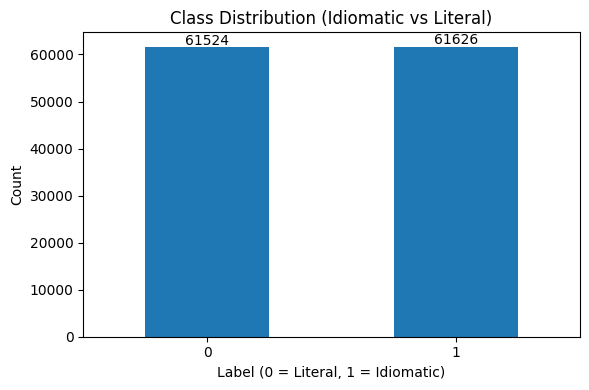

In [18]:
# [3.1] Class balance

label_counts = task1_df["label"].value_counts().sort_index()
label_ratio = (label_counts / len(task1_df)).round(4)

print("Label counts:\n", label_counts)
print("\nLabel ratio:\n", label_ratio)

# Plot
plt.figure(figsize=(6, 4))
label_counts.plot(kind="bar")
plt.title("Class Distribution (Idiomatic vs Literal)")
plt.xlabel("Label (0 = Literal, 1 = Idiomatic)")
plt.ylabel("Count")
plt.xticks(rotation=0)

# Annotate bars
for i, v in enumerate(label_counts.values):
    plt.text(i, v + 500, f"{v}", ha="center")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "class_distribution.png")
plt.show()

The dataset is well-balanced between idiomatic and literal usage, ensuring that models are not biased toward a dominant class.

In [19]:
# [3.2] Idiom distribution

idiom_counts = task1_df["idiom_canonical"].value_counts()

print("Number of unique idioms:", idiom_counts.shape[0])
print("Average samples per idiom:", round(idiom_counts.mean(), 2))

# Top idioms
print("\nTop 10 most frequent idioms:")
print(idiom_counts.head(10))

Number of unique idioms: 14986
Average samples per idiom: 8.22

Top 10 most frequent idioms:
idiom_canonical
dance with the one that brought you     88
Bob's your uncle                        48
you kiss your mother with that mouth    40
worship the porcelain god               40
add fuel to the fire                    32
time heals all wounds                   32
let it be                               32
so help me God                          32
may the Force be with you               32
poverty is a state of mind              32
Name: count, dtype: int64


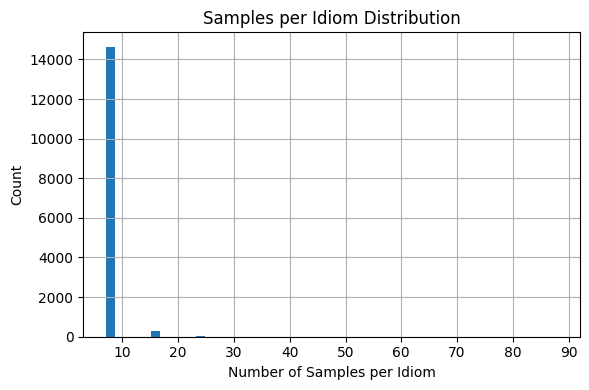

In [20]:
# [3.3] Distribution of samples per idiom

plt.figure(figsize=(6, 4))
idiom_counts.hist(bins=50)
plt.title("Samples per Idiom Distribution")
plt.xlabel("Number of Samples per Idiom")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "idiom_frequency_distribution.png")
plt.show()

In [21]:
# [3.3] Sentence length analysis

task1_df["text_length"] = task1_df["input_text"].str.len()

stats = task1_df["text_length"].describe()

print("Text length statistics:\n")
print(stats)

Text length statistics:

count    123150.0000
mean         70.7912
std          30.1294
min           1.0000
25%          60.0000
50%          75.0000
75%          89.0000
max         623.0000
Name: text_length, dtype: float64


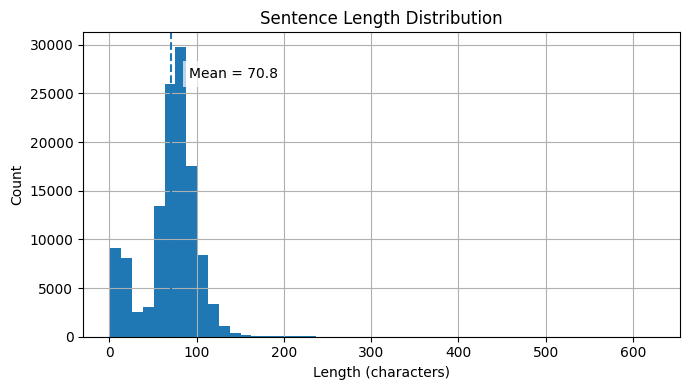

In [27]:
plt.figure(figsize=(7, 4))

task1_df["text_length"].hist(bins=50)

plt.title("Sentence Length Distribution")
plt.xlabel("Length (characters)")
plt.ylabel("Count")

# Mean line
mean_len = task1_df["text_length"].mean()
plt.axvline(mean_len, linestyle="--")

# Move text slightly to the right and higher
plt.text(
    mean_len + 20,                     # shift right
    plt.ylim()[1] * 0.85,             # near top
    f"Mean = {mean_len:.1f}",
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')  # readable box
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "sentence_length_distribution.png")
plt.show()

> Most sentences in the dataset are relatively short, with an average length of around **70 characters**. The majority of examples fall within a narrow range (roughly 40–100 characters), while very long sentences are rare.

> This indicates that the dataset mainly consists of **concise and controlled sentences**, which is suitable for idiom detection since the task relies on understanding short contextual clues rather than long narratives.

> The model is trained on realistic, short-to-medium length sentences, which helps ensure stable learning and reduces noise from overly complex or long inputs.

> This analysis supports that the dataset is well-structured and appropriate for sentence-level idiom detection tasks.

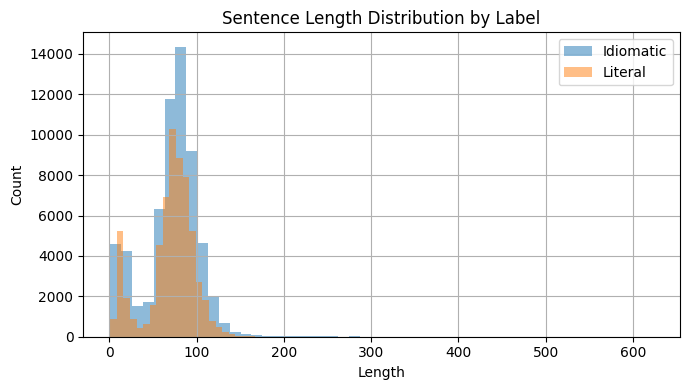

In [25]:
# [3.4] Length vs label

plt.figure(figsize=(7, 4))

task1_df[task1_df["label"] == 1]["text_length"].hist(
    bins=50, alpha=0.5, label="Idiomatic"
)

task1_df[task1_df["label"] == 0]["text_length"].hist(
    bins=50, alpha=0.5, label="Literal"
)

plt.legend()
plt.title("Sentence Length Distribution by Label")
plt.xlabel("Length")
plt.ylabel("Count")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "length_by_label.png")
plt.show()

> The distribution of sentence lengths for both **idiomatic** and **literal** examples is very similar, with most sentences concentrated between roughly **40 and 100 characters**.

> There is no clear difference in length between the two classes, meaning that **sentence length alone is not enough to distinguish idiomatic from literal usage**.

>There is no clear difference in length between the two classes, meaning that **sentence length alone is not enough to distinguish idiomatic from literal usage**.

> This supports the claim that idiom detection is not a surface-level task and requires deeper contextual understanding rather than basic statistical cues.

In [26]:
# [3.5] Difficulty distribution

if "learner_difficulty" in task1_df.columns:
    difficulty_counts = task1_df["learner_difficulty"].value_counts()
    print("Difficulty distribution:\n", difficulty_counts)

# Ambiguity
if "ambiguity_flag" in task1_df.columns:
    ambiguity_counts = task1_df["ambiguity_flag"].value_counts()
    print("\nAmbiguity distribution:\n", ambiguity_counts)

### Key Observations

- The dataset is balanced across classes.
- Idiomatic and literal sentences have highly overlapping length distributions.
- Many examples exhibit semantic ambiguity.
- Difficulty levels are not skewed toward easy cases.

These findings confirm that idiom detection is a non-trivial task requiring semantic understanding rather than surface-level features.

## 4. Data Splitting Strategy

For Task 1, we use a balanced per-idiom split to ensure reproducibility and fair evaluation.

Each idiom is expected to contribute:
- 4 idiomatic examples
- 4 literal examples

We split them as follows:
- **Train:** 2 idiomatic + 2 literal
- **Validation:** 1 idiomatic + 1 literal
- **Test:** 1 idiomatic + 1 literal

This design guarantees balanced class representation within each idiom and avoids unstable random splitting.

## 4. Data Splitting Strategy

For Task 1, we use a controlled per-idiom split.

Idioms with at least four idiomatic and four literal examples are treated as complete idioms and are split as:
- Train: 2 idiomatic + 2 literal
- Validation: 1 idiomatic + 1 literal
- Test: 1 idiomatic + 1 literal

Idioms with incomplete example coverage are retained in the training set only. This increases training coverage while preserving a clean and balanced evaluation protocol.

In [39]:
# [4.1] Prepare Task 1 split dataframe

required_cols = ["idiom_canonical", "idiom_in_example", "example_usage_label"]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

task1_df = df[["idiom_canonical", "idiom_in_example", "example_usage_label"]].copy()

task1_df = task1_df.rename(columns={
    "idiom_in_example": "input_text",
    "example_usage_label": "label_text"
})

task1_df["idiom_canonical"] = task1_df["idiom_canonical"].astype(str).str.strip()
task1_df["input_text"] = task1_df["input_text"].astype(str).str.strip()
task1_df["label_text"] = task1_df["label_text"].astype(str).str.strip().str.lower()

task1_df = task1_df[
    (task1_df["idiom_canonical"] != "") &
    (task1_df["input_text"] != "") &
    (task1_df["label_text"].isin(["idiomatic", "literal"]))
].copy()

task1_df["label"] = task1_df["label_text"].map({
    "literal": 0,
    "idiomatic": 1
}).astype(int)

task1_df = task1_df.drop_duplicates(
    subset=["idiom_canonical", "input_text", "label"]
).reset_index(drop=True)

print("Task 1 clean shape:", task1_df.shape)
print(task1_df["label_text"].value_counts())
display(task1_df.head(5))

Task 1 clean shape: (111490, 4)
label_text
literal      56104
idiomatic    55386
Name: count, dtype: int64


,idiom_canonical,input_text,label_text,label
0,$100 hamburger,"Last weekend, Mark took a $100 hamburger trip just to enjoy flying and have lunch at a local diner.",idiomatic,1
1,$100 hamburger,Pilots often joke about taking a $100 hamburger when planning casual weekend flights.,idiomatic,1
2,$100 hamburger,Her $100 hamburger flight was an excuse for a mini-vacation with friends.,idiomatic,1
3,$100 hamburger,Taking a $100 hamburger is a lighthearted tradition among private pilots to make flying more enjoyable.,idiomatic,1
4,$100 hamburger,The restaurant claims their hamburger costs $100 due to premium ingredients used in the recipe.,literal,0


In [40]:
# [4.2] Check per-idiom coverage

coverage_rows = []

for idiom, group in task1_df.groupby("idiom_canonical"):
    idiomatic_count = int((group["label"] == 1).sum())
    literal_count = int((group["label"] == 0).sum())

    coverage_rows.append({
        "idiom_canonical": idiom,
        "idiomatic_count": idiomatic_count,
        "literal_count": literal_count,
        "is_complete": idiomatic_count >= 4 and literal_count >= 4
    })

coverage_df = pd.DataFrame(coverage_rows)

print("Total idioms:", len(coverage_df))
print("Complete idioms:", int(coverage_df["is_complete"].sum()))
print("Incomplete idioms:", int((~coverage_df["is_complete"]).sum()))

display(coverage_df.head())

Total idioms: 14987
Complete idioms: 12499
Incomplete idioms: 2488


,idiom_canonical,idiomatic_count,literal_count,is_complete
0,$100 hamburger,4,4,True
1,'ark at ee,4,4,True
2,'fraid so,1,4,False
3,'nuff said,4,4,True
4,'tis the season,4,4,True


In [41]:
# [4.3] Split complete idioms using 2/1/1

complete_idioms = coverage_df[coverage_df["is_complete"]]["idiom_canonical"].tolist()

train_parts = []
val_parts = []
test_parts = []

for idiom in complete_idioms:
    group = task1_df[task1_df["idiom_canonical"] == idiom].copy()

    idiomatic_g = group[group["label"] == 1].sample(frac=1, random_state=SEED).reset_index(drop=True)
    literal_g = group[group["label"] == 0].sample(frac=1, random_state=SEED).reset_index(drop=True)

    train_g = pd.concat([idiomatic_g.iloc[:2], literal_g.iloc[:2]], axis=0)
    val_g = pd.concat([idiomatic_g.iloc[2:3], literal_g.iloc[2:3]], axis=0)
    test_g = pd.concat([idiomatic_g.iloc[3:4], literal_g.iloc[3:4]], axis=0)

    train_parts.append(train_g)
    val_parts.append(val_g)
    test_parts.append(test_g)

train_complete_df = pd.concat(train_parts).reset_index(drop=True)
val_df = pd.concat(val_parts).reset_index(drop=True)
test_df = pd.concat(test_parts).reset_index(drop=True)

print("Complete-idiom train shape:", train_complete_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Complete-idiom train shape: (49996, 4)
Validation shape: (24998, 4)
Test shape: (24998, 4)


In [42]:
# [4.4] Add incomplete idioms to training only

incomplete_idioms = coverage_df[~coverage_df["is_complete"]]["idiom_canonical"].tolist()

train_incomplete_df = task1_df[
    task1_df["idiom_canonical"].isin(incomplete_idioms)
].copy()

train_df = pd.concat([train_complete_df, train_incomplete_df], axis=0)
train_df = train_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

val_df = val_df.sample(frac=1, random_state=SEED).reset_index(drop=True)
test_df = test_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print("Final train shape:", train_df.shape)
print("Validation shape :", val_df.shape)
print("Test shape       :", test_df.shape)

Final train shape: (58699, 4)
Validation shape : (24998, 4)
Test shape       : (24998, 4)


In [43]:
# [4.5] Verify final split distributions

def describe_split(df_split, name):
    print(f"\n{name} shape: {df_split.shape}")
    print(df_split["label_text"].value_counts())

describe_split(train_df, "Train")
describe_split(val_df, "Validation")
describe_split(test_df, "Test")

print("\nIdiom summary:")
print("Complete idioms used for benchmark split :", len(complete_idioms))
print("Incomplete idioms kept in training only  :", len(incomplete_idioms))


Train shape: (58699, 4)
label_text
literal      29678
idiomatic    29021
Name: count, dtype: int64

Validation shape: (24998, 4)
label_text
idiomatic    12499
literal      12499
Name: count, dtype: int64

Test shape: (24998, 4)
label_text
idiomatic    12499
literal      12499
Name: count, dtype: int64

Idiom summary:
Complete idioms used for benchmark split : 12499
Incomplete idioms kept in training only  : 2488


In [44]:
# [4.6] Save split artifacts and metadata

import json

train_path = OUTPUTS_DIR / "task1_train_split.csv"
val_path = OUTPUTS_DIR / "task1_validation_split.csv"
test_path = OUTPUTS_DIR / "task1_test_split.csv"

coverage_path = OUTPUTS_DIR / "task1_idiom_coverage.csv"
meta_path = OUTPUTS_DIR / "task1_split_metadata.json"

train_df.to_csv(train_path, index=False, encoding="utf-8")
val_df.to_csv(val_path, index=False, encoding="utf-8")
test_df.to_csv(test_path, index=False, encoding="utf-8")
coverage_df.to_csv(coverage_path, index=False, encoding="utf-8")

split_metadata = {
    "seed": SEED,
    "strategy": {
        "complete_idioms": "2 idiomatic + 2 literal train, 1 idiomatic + 1 literal validation, 1 idiomatic + 1 literal test",
        "incomplete_idioms": "all examples kept in training only"
    },
    "task1_clean_shape": int(len(task1_df)),
    "train_size": int(len(train_df)),
    "validation_size": int(len(val_df)),
    "test_size": int(len(test_df)),
    "complete_idiom_count": int(len(complete_idioms)),
    "incomplete_idiom_count": int(len(incomplete_idioms))
}

with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(split_metadata, f, indent=4, ensure_ascii=False)

print("Saved:")
print(train_path)
print(val_path)
print(test_path)
print(coverage_path)
print(meta_path)

Saved:
C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\outputs\task1_idiom_detection\task1_train_split.csv
C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\outputs\task1_idiom_detection\task1_validation_split.csv
C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\outputs\task1_idiom_detection\task1_test_split.csv
C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\outputs\task1_idiom_detection\task1_idiom_coverage.csv
C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\outputs\task1_idiom_detection\task1_split_metadata.json


## 4.7 Split Visualization

We visualize the resulting train, validation, and test splits to confirm:
- class balance across splits
- relative split sizes
- idiom coverage used for benchmarking

These figures are saved for later use in the paper.

,Train,Validation,Test
label_text,,,
idiomatic,29021,12499,12499
literal,29678,12499,12499


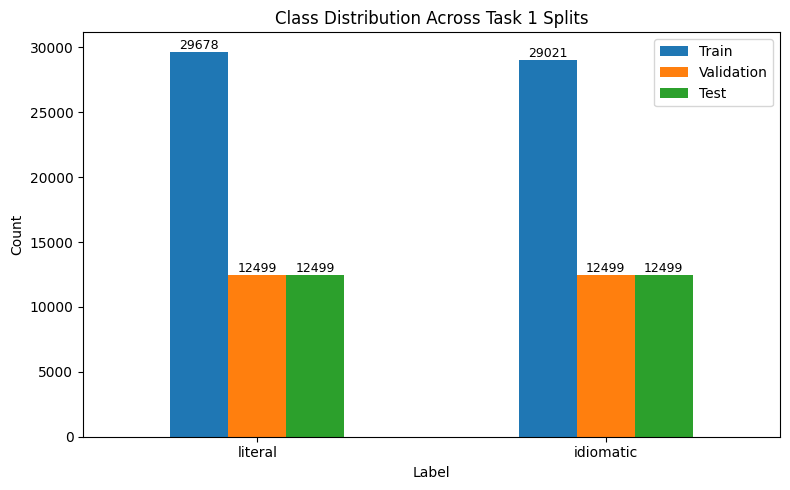

Saved figures:
C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\outputs\task1_idiom_detection\figures\task1_split_class_distribution.png


In [46]:
# [4.7] Split visualization charts

import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------
# Build class distribution table
# -----------------------------
split_dist_df = pd.DataFrame({
    "Train": train_df["label_text"].value_counts(),
    "Validation": val_df["label_text"].value_counts(),
    "Test": test_df["label_text"].value_counts()
}).fillna(0).astype(int)

display(split_dist_df)

# -----------------------------
# Chart 1: Class distribution across splits
# -----------------------------
ax = split_dist_df.loc[["literal", "idiomatic"]].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Class Distribution Across Task 1 Splits")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=0)

# annotate values
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.savefig(FIGURES_DIR / "task1_split_class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved figures:")
print(FIGURES_DIR / "task1_split_class_distribution.png")

> The dataset is **perfectly balanced** between the two classes (literal and idiomatic) across the training, validation, and test sets.

> The evaluation results are reliable and fair, as the model is tested under balanced conditions without class imbalance influencing performance.


> This confirms that the dataset splitting strategy preserves class balance, allowing for unbiased comparison of model performance across all splits.

,Split,Rows
0,Train,58699
1,Validation,24998
2,Test,24998


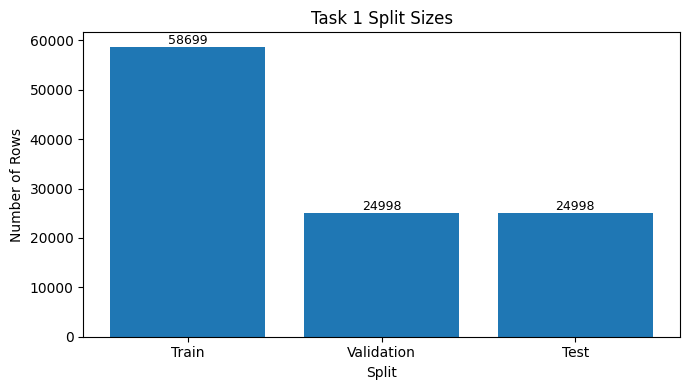

Saved figures:
C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\outputs\task1_idiom_detection\figures\task1_split_sizes.png


In [47]:
# [4.8] Split size summary
# -----------------------------
split_size_df = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Rows": [len(train_df), len(val_df), len(test_df)]
})

display(split_size_df)

# -----------------------------
# Chart 2: Split sizes
# -----------------------------
plt.figure(figsize=(7, 4))
bars = plt.bar(split_size_df["Split"], split_size_df["Rows"])

plt.title("Task 1 Split Sizes")
plt.xlabel("Split")
plt.ylabel("Number of Rows")

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval,
        f"{int(yval)}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.savefig(FIGURES_DIR / "task1_split_sizes.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved figures:")
print(FIGURES_DIR / "task1_split_sizes.png")

,Category,Count
0,Complete idioms (benchmark split),12499
1,Incomplete idioms (train only),2488


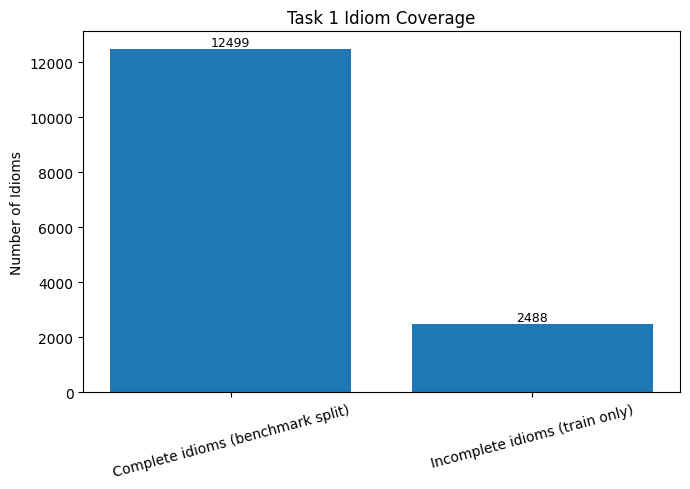

Saved figures:
C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\outputs\task1_idiom_detection\figures\task1_idiom_coverage.png


In [49]:
# [4.9] Idiom coverage summary
# -----------------------------
idiom_summary_df = pd.DataFrame({
    "Category": ["Complete idioms (benchmark split)", "Incomplete idioms (train only)"],
    "Count": [len(complete_idioms), len(incomplete_idioms)]
})

display(idiom_summary_df)

# -----------------------------
# Chart 3: Idiom coverage
# -----------------------------
plt.figure(figsize=(7, 5))
bars = plt.bar(idiom_summary_df["Category"], idiom_summary_df["Count"])

plt.title("Task 1 Idiom Coverage")
plt.ylabel("Number of Idioms")
plt.xticks(rotation=15)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval,
        f"{int(yval)}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.savefig(FIGURES_DIR / "task1_idiom_coverage.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved figures:")
print(FIGURES_DIR / "task1_idiom_coverage.png")

## 5. Baseline Model: Logistic Regression with TF-IDF

We first train a classical lexical baseline using TF-IDF features and Logistic Regression.

To support reproducibility and avoid unnecessary retraining, the notebook saves:
- the fitted vectorizer
- the trained model
- evaluation metrics
- prediction files

In [51]:
# [5.1.1] Baseline paths and configuration

import json
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

BASELINE_DIR = MODELS_DIR / "logistic_regression_baseline"
BASELINE_DIR.mkdir(parents=True, exist_ok=True)

vectorizer_path = BASELINE_DIR / "tfidf_vectorizer.joblib"
model_path = BASELINE_DIR / "logreg_model.joblib"
config_path = BASELINE_DIR / "baseline_config.json"

baseline_config = {
    "model_name": "Logistic Regression",
    "feature_type": "TF-IDF",
    "ngram_range": (1, 2),
    "max_features": 50000,
    "random_state": SEED,
    "max_iter": 1000
}

print("Baseline directory:", BASELINE_DIR)
print("Vectorizer exists:", vectorizer_path.exists())
print("Model exists:", model_path.exists())

Baseline directory: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\models\task1_idiom_detection\logistic_regression_baseline
Vectorizer exists: True
Model exists: True


In [52]:
# [5.1.2] Prepare text inputs and labels

X_train_text = train_df["input_text"].tolist()
X_val_text = val_df["input_text"].tolist()
X_test_text = test_df["input_text"].tolist()

y_train = train_df["label"].values
y_val = val_df["label"].values
y_test = test_df["label"].values

print("Train texts:", len(X_train_text))
print("Validation texts:", len(X_val_text))
print("Test texts:", len(X_test_text))

Train texts: 58699
Validation texts: 24998
Test texts: 24998


In [53]:
# [5.1.3] Train or load baseline model

if vectorizer_path.exists() and model_path.exists():
    print("Loading saved Logistic Regression baseline...")
    vectorizer = joblib.load(vectorizer_path)
    logreg_model = joblib.load(model_path)
else:
    print("Training Logistic Regression baseline...")

    vectorizer = TfidfVectorizer(
        ngram_range=baseline_config["ngram_range"],
        max_features=baseline_config["max_features"]
    )

    X_train = vectorizer.fit_transform(X_train_text)

    logreg_model = LogisticRegression(
        random_state=baseline_config["random_state"],
        max_iter=baseline_config["max_iter"]
    )

    logreg_model.fit(X_train, y_train)

    joblib.dump(vectorizer, vectorizer_path)
    joblib.dump(logreg_model, model_path)

    with open(config_path, "w", encoding="utf-8") as f:
        json.dump(baseline_config, f, indent=4)

    print("Saved vectorizer and model.")

Loading saved Logistic Regression baseline...


In [54]:
# [5.1.4] Transform train, validation, and test text

X_train = vectorizer.transform(X_train_text)
X_val = vectorizer.transform(X_val_text)
X_test = vectorizer.transform(X_test_text)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

X_train shape: (58699, 50000)
X_val shape: (24998, 50000)
X_test shape: (24998, 50000)


In [55]:
# [5.1.5] Generate predictions

train_pred = logreg_model.predict(X_train)
val_pred = logreg_model.predict(X_val)
test_pred = logreg_model.predict(X_test)

val_prob = logreg_model.predict_proba(X_val)[:, 1]
test_prob = logreg_model.predict_proba(X_test)[:, 1]

print("Predictions generated.")

Predictions generated.


In [56]:
# [5.1.6] Compute and save metrics

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

train_metrics_path = BASELINE_DIR / "train_metrics.json"
val_metrics_path = BASELINE_DIR / "validation_metrics.json"
test_metrics_path = BASELINE_DIR / "test_metrics.json"

def compute_metrics(y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary"
    )
    acc = accuracy_score(y_true, y_pred)
    return {
        "accuracy": float(acc),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1)
    }

train_metrics = compute_metrics(y_train, train_pred)
val_metrics = compute_metrics(y_val, val_pred)
test_metrics = compute_metrics(y_test, test_pred)

with open(train_metrics_path, "w", encoding="utf-8") as f:
    json.dump(train_metrics, f, indent=4)

with open(val_metrics_path, "w", encoding="utf-8") as f:
    json.dump(val_metrics, f, indent=4)

with open(test_metrics_path, "w", encoding="utf-8") as f:
    json.dump(test_metrics, f, indent=4)

print("Train metrics:", train_metrics)
print("Validation metrics:", val_metrics)
print("Test metrics:", test_metrics)

print("\nValidation classification report:")
print(classification_report(y_val, val_pred, digits=4))

print("Test classification report:")
print(classification_report(y_test, test_pred, digits=4))

Train metrics: {'accuracy': 0.8528424675037053, 'precision': 0.8498987194012428, 'recall': 0.8530029978291582, 'f1': 0.8514480291669533}
Validation metrics: {'accuracy': 0.8533482678614289, 'precision': 0.871352896661902, 'recall': 0.8291063285062805, 'f1': 0.8497048212528698}
Test metrics: {'accuracy': 0.8536282902632211, 'precision': 0.8475935828877005, 'recall': 0.8623089847187775, 'f1': 0.8548879635137815}

Validation classification report:
              precision    recall  f1-score   support

           0     0.8370    0.8776    0.8568     12499
           1     0.8714    0.8291    0.8497     12499

    accuracy                         0.8533     24998
   macro avg     0.8542    0.8533    0.8533     24998
weighted avg     0.8542    0.8533    0.8533     24998

Test classification report:
              precision    recall  f1-score   support

           0     0.8599    0.8449    0.8523     12499
           1     0.8476    0.8623    0.8549     12499

    accuracy                    

> The Logistic Regression model achieves an overall accuracy of around **85%** on both validation and test sets, with balanced precision and recall across both classes.

> Performance is consistent across validation and test data, indicating that the model generalizes well and is not overfitting.

> However, the model shows slightly lower recall for idiomatic expressions compared to literal ones, meaning it sometimes **misses idiomatic usage**.

> Logistic Regression provides a strong baseline using simple features, but its performance is limited when deeper contextual understanding is required.

> This baseline demonstrates that while surface-level models can capture useful patterns, more advanced models are needed to better handle semantic and contextual aspects of idiom detection.

In [57]:
# [5.1.7] Save validation and test predictions

val_predictions_path = BASELINE_DIR / "validation_predictions.csv"
test_predictions_path = BASELINE_DIR / "test_predictions.csv"

val_out = val_df.copy()
val_out["pred_label"] = val_pred
val_out["pred_prob_idiomatic"] = val_prob
val_out.to_csv(val_predictions_path, index=False, encoding="utf-8")

test_out = test_df.copy()
test_out["pred_label"] = test_pred
test_out["pred_prob_idiomatic"] = test_prob
test_out.to_csv(test_predictions_path, index=False, encoding="utf-8")

print("Saved:")
print(val_predictions_path)
print(test_predictions_path)

Saved:
C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\models\task1_idiom_detection\logistic_regression_baseline\validation_predictions.csv
C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\models\task1_idiom_detection\logistic_regression_baseline\test_predictions.csv


## 5.2 Confusion Matrix (Baseline)

We analyze the prediction behavior of the Logistic Regression baseline using a confusion matrix on the test set.

This helps identify:
- false positives (literal → idiomatic)
- false negatives (idiomatic → literal)

The figure is saved for later inclusion in the paper.

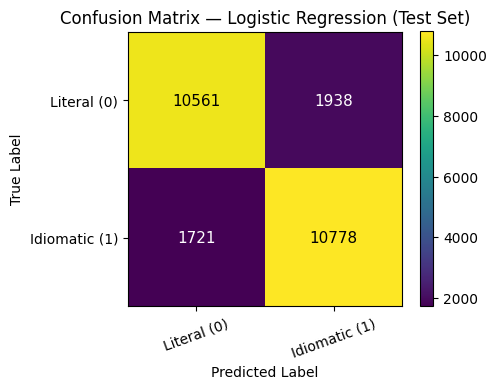

Saved: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\outputs\task1_idiom_detection\figures\task1_logreg_confusion_matrix.png


In [62]:
# [5.2] Confusion Matrix (Test set)

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_test, test_pred)

labels = ["Literal (0)", "Idiomatic (1)"]

plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix — Logistic Regression (Test Set)")
plt.colorbar()

tick_marks = np.arange(len(labels))
plt.xticks(tick_marks, labels, rotation=20)
plt.yticks(tick_marks, labels)

# annotate values with adaptive color
threshold = cm.max() / 2

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i,
            f"{cm[i, j]}",
            ha="center",
            va="center",
            fontsize=11,
            color="black" if cm[i, j] > threshold else "white"
        )

plt.ylabel("True Label")
plt.xlabel("Predicted Label")

plt.tight_layout()

cm_path = FIGURES_DIR / "task1_logreg_confusion_matrix.png"
plt.savefig(cm_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved:", cm_path)

The model correctly classifies a large number of both **literal** and **idiomatic** sentences, showing balanced performance across the two classes.

However, there are noticeable errors:
- Around **1,938 literal sentences** are incorrectly predicted as idiomatic (false positives)
- Around **1,721 idiomatic sentences** are missed and predicted as literal (false negatives)

This shows that the model sometimes struggles to distinguish between literal and figurative meanings when the wording is similar.

**Conclusion:**  
While the model performs well overall, it still makes mistakes in ambiguous cases where idiomatic and literal expressions share similar vocabulary.

> The confusion matrix highlights that errors are relatively balanced between the two classes, confirming that the model does not strongly favor one class over the other, but still lacks deeper semantic understanding in challenging cases.

## 5.3 ROC Curve and AUC (Baseline)

We evaluate the classification quality using ROC curve and Area Under Curve (AUC).

This provides a threshold-independent view of model performance and is important for comparing models.

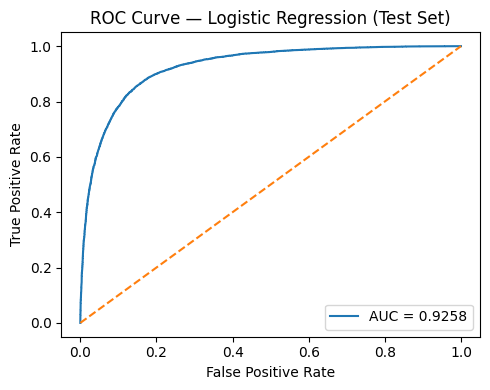

AUC: 0.9258410790472646
Saved: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\outputs\task1_idiom_detection\figures\task1_logreg_roc_curve.png


In [63]:
# [5.3] ROC Curve and AUC (Test set)

from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, test_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Logistic Regression (Test Set)")
plt.legend(loc="lower right")

plt.tight_layout()

roc_path = FIGURES_DIR / "task1_logreg_roc_curve.png"
plt.savefig(roc_path, dpi=300, bbox_inches="tight")

plt.show()

print("AUC:", roc_auc)
print("Saved:", roc_path)

## 5.4 Error Analysis (Baseline)

We analyze prediction errors of the Logistic Regression baseline to understand:
- common failure cases
- types of confusion between literal and idiomatic usage

We focus on:
- False Positives (literal predicted as idiomatic)
- False Negatives (idiomatic predicted as literal)

Sample examples are extracted for qualitative analysis.

In [64]:
# [5.4.1] Build error analysis dataframe (LogReg)

logreg_test_df = test_df.copy()

logreg_test_df["logreg_pred"] = test_pred
logreg_test_df["logreg_prob"] = test_prob

# error flags
logreg_test_df["is_correct"] = (logreg_test_df["label"] == logreg_test_df["logreg_pred"])

# false positives: literal → idiomatic
logreg_fp = logreg_test_df[
    (logreg_test_df["label"] == 0) & (logreg_test_df["logreg_pred"] == 1)
]

# false negatives: idiomatic → literal
logreg_fn = logreg_test_df[
    (logreg_test_df["label"] == 1) & (logreg_test_df["logreg_pred"] == 0)
]

print("Total test samples:", len(logreg_test_df))
print("Correct predictions:", logreg_test_df["is_correct"].sum())
print("False Positives:", len(logreg_fp))
print("False Negatives:", len(logreg_fn))

Total test samples: 24998
Correct predictions: 21339
False Positives: 1938
False Negatives: 1721


In [65]:
# [5.4.2] Top confident errors (most important for analysis)

# High-confidence wrong predictions
logreg_fp_sorted = logreg_fp.sort_values("logreg_prob", ascending=False)
logreg_fn_sorted = logreg_fn.sort_values("logreg_prob", ascending=True)

print("\nTop False Positives (literal → idiomatic):")
display(logreg_fp_sorted[["input_text", "label_text", "logreg_pred", "logreg_prob"]].head(5))

print("\nTop False Negatives (idiomatic → literal):")
display(logreg_fn_sorted[["input_text", "label_text", "logreg_pred", "logreg_prob"]].head(5))


Top False Positives (literal → idiomatic):


,input_text,label_text,logreg_pred,logreg_prob
19359,"You think about your future plans often, don’t you?",literal,1,0.9842
18706,"All things considered, the project was a success.",literal,1,0.9803
7968,The company's vision is not just a buzzword but a defined term that guides all strategic decisions.,literal,1,0.9738
17891,His explanation revealed a breach of promise in his commitment to support the project.,literal,1,0.9689
16367,"Their relationship felt like being at war, with constant arguments and no peace.",literal,1,0.9673



Top False Negatives (idiomatic → literal):


,input_text,label_text,logreg_pred,logreg_prob
5765,The hikers waited out the night in the tent during the heavy rainfall.,idiomatic,0,0.0236
9286,We had to inch along the narrow ledge carefully to stay safe.,idiomatic,0,0.0324
359,The children get sick after playing outside in the cold rain.,idiomatic,0,0.0330
14813,"When caught in the storm, we had to take soil near the river to stay hidden from the enemy.",idiomatic,0,0.0364
9660,The garden flowers are springing up early this year due to the warm weather.,idiomatic,0,0.0439


In [66]:
# [5.4.3] Random error samples

print("\nRandom False Positives:")
display(logreg_fp.sample(5, random_state=SEED)[["input_text", "logreg_prob"]])

print("\nRandom False Negatives:")
display(logreg_fn.sample(5, random_state=SEED)[["input_text", "logreg_prob"]])


Random False Positives:


,input_text,logreg_prob
7601,look over her shoulder,0.7587
11536,"In the psychology book, there's a thought that suggests emotions influence decision-making.",0.8087
11676,She tried to turn a blind eye to the sudden movement in her peripheral vision by closing one eye quickly.,0.5339
22502,The last big thing at the conference was the keynote speaker’s bold announcement.,0.8252
18948,She spends much less money now that she has started budgeting.,0.8839



Random False Negatives:


,input_text,logreg_prob
10892,"The festival featured all manner of music genres, from classical to hip-hop.",0.4528
12664,He painted the fence with a lick and a promise so he could finish before dark.,0.1371
8862,"During the event, several volunteers gave the speaker a hand by setting up the stage.",0.2525
23672,The new shopping center is literally a yardarm to the old mall downtown.,0.1537
3770,"When the teacher found plagiarized work, the student got a trip to the woodshed in the principal's office.",0.4824


In [67]:
# [5.4.4] Save error analysis outputs

logreg_fp_path = BASELINE_DIR / "false_positives.csv"
logreg_fn_path = BASELINE_DIR / "false_negatives.csv"

logreg_fp.to_csv(logreg_fp_path, index=False, encoding="utf-8")
logreg_fn.to_csv(logreg_fn_path, index=False, encoding="utf-8")

print("Saved:")
print(logreg_fp_path)
print(logreg_fn_path)

Saved:
C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\models\task1_idiom_detection\logistic_regression_baseline\false_positives.csv
C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\models\task1_idiom_detection\logistic_regression_baseline\false_negatives.csv


Error analysis reveals that the Logistic Regression baseline frequently misclassifies literal sentences containing idiomatic expressions as idiomatic (false positives), indicating reliance on surface lexical cues. Conversely, idiomatic expressions requiring contextual interpretation are often missed (false negatives).

---

## 5.5 Model 2: RoBERTa

We next evaluate a transformer-based contextual model using RoBERTa.

Compared with the lexical baseline, RoBERTa can model contextual meaning more effectively and is expected to perform better on idiomatic usage detection.

To ensure reproducibility, the model, tokenizer, metrics, and prediction files are saved to disk and reused if they already exist.

In [68]:
# [5.5.1] RoBERTa paths and configuration

import json
from pathlib import Path

ROBERTA_DIR = MODELS_DIR / "roberta_base"
ROBERTA_DIR.mkdir(parents=True, exist_ok=True)

roberta_model_path = ROBERTA_DIR / "model"
roberta_tokenizer_path = ROBERTA_DIR / "tokenizer"
roberta_train_metrics_path = ROBERTA_DIR / "train_metrics.json"
roberta_val_metrics_path = ROBERTA_DIR / "validation_metrics.json"
roberta_test_metrics_path = ROBERTA_DIR / "test_metrics.json"
roberta_val_predictions_path = ROBERTA_DIR / "validation_predictions.csv"
roberta_test_predictions_path = ROBERTA_DIR / "test_predictions.csv"
roberta_config_path = ROBERTA_DIR / "roberta_config.json"

roberta_config = {
    "hf_model_name": "roberta-base",
    "max_length": 128,
    "num_train_epochs": 2,
    "train_batch_size": 16,
    "eval_batch_size": 32,
    "learning_rate": 2e-5,
    "weight_decay": 0.01,
    "random_state": SEED
}

print("ROBERTA_DIR:", ROBERTA_DIR)
print("Model exists:", roberta_model_path.exists())
print("Tokenizer exists:", roberta_tokenizer_path.exists())

ROBERTA_DIR: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\models\task1_idiom_detection\roberta_base
Model exists: False
Tokenizer exists: False


In [69]:
# [5.5.2] Imports and device setup

import numpy as np
import pandas as pd
import torch

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

roberta_device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", roberta_device)

Device: cuda


In [70]:
# [5.5.3] Prepare RoBERTa input data

roberta_train_df = train_df[["input_text", "label"]].copy().reset_index(drop=True)
roberta_val_df = val_df[["input_text", "label"]].copy().reset_index(drop=True)
roberta_test_df = test_df[["input_text", "label"]].copy().reset_index(drop=True)

print("Train:", roberta_train_df.shape)
print("Validation:", roberta_val_df.shape)
print("Test:", roberta_test_df.shape)

display(roberta_train_df.head(3))

Train: (58699, 2)
Validation: (24998, 2)
Test: (24998, 2)


,input_text,label
0,The jeweler examined the diamond in the rough before deciding how to cut it.,0
1,Make sure enough flour is added to the mixture for the cake to rise.,0
2,"If you are angry at me, please don't @ me on social media tonight.",0


In [71]:
# [5.5.4] Convert to Hugging Face datasets

roberta_train_ds = Dataset.from_pandas(roberta_train_df)
roberta_val_ds = Dataset.from_pandas(roberta_val_df)
roberta_test_ds = Dataset.from_pandas(roberta_test_df)

print(roberta_train_ds)
print(roberta_val_ds)
print(roberta_test_ds)

Dataset({
    features: ['input_text', 'label'],
    num_rows: 58699
})
Dataset({
    features: ['input_text', 'label'],
    num_rows: 24998
})
Dataset({
    features: ['input_text', 'label'],
    num_rows: 24998
})


In [72]:
# [5.5.5] Train or load tokenizer

from transformers import AutoTokenizer

if roberta_tokenizer_path.exists():
    print("Loading saved tokenizer...")
    roberta_tokenizer = AutoTokenizer.from_pretrained(roberta_tokenizer_path)
else:
    print("Loading tokenizer from Hugging Face...")
    roberta_tokenizer = AutoTokenizer.from_pretrained(roberta_config["hf_model_name"])
    roberta_tokenizer.save_pretrained(roberta_tokenizer_path)
    print("Saved tokenizer.")

Loading tokenizer from Hugging Face...
Saved tokenizer.


In [73]:
# [5.5.6] Tokenization function

def roberta_tokenize(batch):
    return roberta_tokenizer(
        batch["input_text"],
        truncation=True,
        padding="max_length",
        max_length=roberta_config["max_length"]
    )

In [74]:
# [5.5.7] Tokenize datasets

roberta_train_ds_tok = roberta_train_ds.map(roberta_tokenize, batched=True)
roberta_val_ds_tok = roberta_val_ds.map(roberta_tokenize, batched=True)
roberta_test_ds_tok = roberta_test_ds.map(roberta_tokenize, batched=True)

roberta_train_ds_tok = roberta_train_ds_tok.rename_column("label", "labels")
roberta_val_ds_tok = roberta_val_ds_tok.rename_column("label", "labels")
roberta_test_ds_tok = roberta_test_ds_tok.rename_column("label", "labels")

roberta_train_ds_tok.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
roberta_val_ds_tok.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
roberta_test_ds_tok.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

print("Tokenization complete.")

Map:   0%|          | 0/58699 [00:00<?, ? examples/s]

Map:   0%|          | 0/24998 [00:00<?, ? examples/s]

Map:   0%|          | 0/24998 [00:00<?, ? examples/s]

Tokenization complete.


In [75]:
# [5.5.8] Metrics function

def roberta_compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary"
    )
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [76]:
# [5.5.9] Load or initialize RoBERTa model

from transformers import AutoModelForSequenceClassification

if roberta_model_path.exists():
    print("Loading saved RoBERTa model...")
    roberta_model = AutoModelForSequenceClassification.from_pretrained(roberta_model_path)
else:
    print("Initializing roberta-base from Hugging Face...")
    roberta_model = AutoModelForSequenceClassification.from_pretrained(
        roberta_config["hf_model_name"],
        num_labels=2
    )

Initializing roberta-base from Hugging Face...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [77]:
# [5.5.10] Training arguments

roberta_training_args = TrainingArguments(
    output_dir=str(ROBERTA_DIR / "checkpoints"),
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=roberta_config["learning_rate"],
    per_device_train_batch_size=roberta_config["train_batch_size"],
    per_device_eval_batch_size=roberta_config["eval_batch_size"],
    num_train_epochs=roberta_config["num_train_epochs"],
    weight_decay=roberta_config["weight_decay"],
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none",
    seed=SEED
)

print("Training arguments ready.")

Training arguments ready.


In [78]:
# [5.5.11] Create Trainer

roberta_trainer = Trainer(
    model=roberta_model,
    args=roberta_training_args,
    train_dataset=roberta_train_ds_tok,
    eval_dataset=roberta_val_ds_tok,
    tokenizer=roberta_tokenizer,
    compute_metrics=roberta_compute_metrics
)

print("RoBERTa trainer created.")

RoBERTa trainer created.


In [79]:
# [5.5.12] Train only if model is not already saved

if roberta_model_path.exists():
    print("Saved RoBERTa model already exists. Skipping training.")
else:
    print("Training RoBERTa...")
    roberta_trainer.train()

    roberta_trainer.save_model(roberta_model_path)
    roberta_tokenizer.save_pretrained(roberta_tokenizer_path)

    with open(roberta_config_path, "w", encoding="utf-8") as f:
        json.dump(roberta_config, f, indent=4)

    print("Saved trained RoBERTa model and config.")

Training RoBERTa...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.363400,0.297839,0.874750,0.960389,0.781743,0.861906
2,0.266400,0.231236,0.916633,0.932265,0.898552,0.915098


Saved trained RoBERTa model and config.


In [90]:
# [5.5.x-alt] Save tokenizer only if model already trained but tokenizer folder missing

from transformers import AutoTokenizer
import json

if not roberta_tokenizer_path.exists():
    roberta_tokenizer = AutoTokenizer.from_pretrained(roberta_config["hf_model_name"])
    roberta_tokenizer.save_pretrained(roberta_tokenizer_path)
    print("Tokenizer folder created at:", roberta_tokenizer_path)
else:
    print("Tokenizer already exists:", roberta_tokenizer_path)

if not roberta_config_path.exists():
    with open(roberta_config_path, "w", encoding="utf-8") as f:
        json.dump(roberta_config, f, indent=4, ensure_ascii=False)
    print("Config saved at:", roberta_config_path)
else:
    print("Config already exists:", roberta_config_path)

Tokenizer already exists: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\models\task1_idiom_detection\roberta_base\tokenizer
Config already exists: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\models\task1_idiom_detection\roberta_base\roberta_config.json


## 5.6 Reproducible RoBERTa Inference

In this section, we reload the saved RoBERTa model and tokenizer, rebuild the validation dataset, and generate predictions in a fully reproducible way.

This section does not depend on the in-memory training state.

In [94]:
# [5.6.1] Check saved RoBERTa artifacts

print("Model path exists    :", roberta_model_path.exists())
print("Tokenizer path exists:", roberta_tokenizer_path.exists())
print("Config path exists   :", roberta_config_path.exists())

Model path exists    : True
Tokenizer path exists: True
Config path exists   : True


In [95]:
# [5.6.2] Load saved tokenizer and model

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

roberta_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", roberta_device)

roberta_tokenizer_loaded = AutoTokenizer.from_pretrained(roberta_tokenizer_path)
roberta_model_loaded = AutoModelForSequenceClassification.from_pretrained(roberta_model_path)

roberta_model_loaded.to(roberta_device)
roberta_model_loaded.eval()

print("RoBERTa model and tokenizer loaded successfully.")

Device: cuda
RoBERTa model and tokenizer loaded successfully.


In [96]:
# [5.6.3] Prepare validation dataframe

roberta_val_eval_df = val_df[["input_text", "label", "label_text"]].copy().reset_index(drop=True)

print("Validation dataframe shape:", roberta_val_eval_df.shape)
display(roberta_val_eval_df.head(3))

Validation dataframe shape: (24998, 3)


,input_text,label,label_text
0,"Despite having an embarrassment of riches in the dessert buffet, she only picked a small piece of cake.",1,idiomatic
1,"These students were quite capable of tugging their forelocks while raising two fingers behind their backs, producing...",1,idiomatic
2,The company’s future is hanging by a thread after the recent financial losses that nearly bankrupted it.,1,idiomatic


In [97]:
# [5.6.4] Convert validation dataframe to Hugging Face dataset

from datasets import Dataset

roberta_val_eval_ds = Dataset.from_pandas(
    roberta_val_eval_df[["input_text", "label"]]
)

print(roberta_val_eval_ds)

Dataset({
    features: ['input_text', 'label'],
    num_rows: 24998
})


In [98]:
# [5.6.5] Tokenize validation dataset

def roberta_eval_tokenize(batch):
    return roberta_tokenizer_loaded(
        batch["input_text"],
        truncation=True,
        padding="max_length",
        max_length=roberta_config["max_length"]
    )

roberta_val_eval_ds = roberta_val_eval_ds.map(roberta_eval_tokenize, batched=True)
roberta_val_eval_ds = roberta_val_eval_ds.rename_column("label", "labels")
roberta_val_eval_ds.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

print("Tokenization complete.")

Map:   0%|          | 0/24998 [00:00<?, ? examples/s]

Tokenization complete.


In [99]:
# [5.6.6] Create validation dataloader

from torch.utils.data import DataLoader

roberta_val_loader = DataLoader(
    roberta_val_eval_ds,
    batch_size=roberta_config["eval_batch_size"],
    shuffle=False
)

print("Validation dataloader ready.")

Validation dataloader ready.


In [100]:
# [5.6.7] Run batched inference

import numpy as np

roberta_val_all_logits = []
roberta_val_all_probs = []
roberta_val_all_preds = []
roberta_val_all_labels = []

with torch.no_grad():
    for batch in roberta_val_loader:
        input_ids = batch["input_ids"].to(roberta_device)
        attention_mask = batch["attention_mask"].to(roberta_device)
        labels = batch["labels"].to(roberta_device)

        outputs = roberta_model_loaded(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        roberta_val_all_logits.append(logits.cpu().numpy())
        roberta_val_all_probs.append(probs.cpu().numpy())
        roberta_val_all_preds.append(preds.cpu().numpy())
        roberta_val_all_labels.append(labels.cpu().numpy())

print("Inference complete.")

Inference complete.


In [101]:
# [5.6.8] Merge prediction outputs

roberta_val_logits = np.concatenate(roberta_val_all_logits, axis=0)
roberta_val_probs = np.concatenate(roberta_val_all_probs, axis=0)
roberta_val_preds = np.concatenate(roberta_val_all_preds, axis=0)
roberta_val_labels = np.concatenate(roberta_val_all_labels, axis=0)

print("Predictions shape :", roberta_val_preds.shape)
print("Probabilities shape:", roberta_val_probs.shape)

Predictions shape : (24998,)
Probabilities shape: (24998, 2)


In [102]:
# [5.6.9] Build validation analysis dataframe

roberta_val_analysis_df = roberta_val_eval_df.copy()

roberta_val_analysis_df["roberta_pred"] = roberta_val_preds
roberta_val_analysis_df["roberta_prob_literal"] = roberta_val_probs[:, 0]
roberta_val_analysis_df["roberta_prob_idiomatic"] = roberta_val_probs[:, 1]
roberta_val_analysis_df["roberta_correct"] = (
    roberta_val_analysis_df["label"] == roberta_val_analysis_df["roberta_pred"]
)

display(roberta_val_analysis_df.head(5))

,input_text,label,label_text,roberta_pred,roberta_prob_literal,roberta_prob_idiomatic,roberta_correct
0,"Despite having an embarrassment of riches in the dessert buffet, she only picked a small piece of cake.",1,idiomatic,1,0.0382,0.9618,True
1,"These students were quite capable of tugging their forelocks while raising two fingers behind their backs, producing...",1,idiomatic,1,0.3283,0.6717,True
2,The company’s future is hanging by a thread after the recent financial losses that nearly bankrupted it.,1,idiomatic,1,0.0012,0.9988,True
3,"Out of a pool of 20 applicants, only three made the cut.",1,idiomatic,1,0.0018,0.9982,True
4,"The fencing match was intense, with the opponent making moves up to scratch near the boundary line.",0,literal,0,0.9514,0.0486,True


In [103]:
# [5.6.10] Extract false positives and false negatives

roberta_val_fp_df = roberta_val_analysis_df[
    (roberta_val_analysis_df["label"] == 0) &
    (roberta_val_analysis_df["roberta_pred"] == 1)
].copy()

roberta_val_fn_df = roberta_val_analysis_df[
    (roberta_val_analysis_df["label"] == 1) &
    (roberta_val_analysis_df["roberta_pred"] == 0)
].copy()

print("Total validation rows:", len(roberta_val_analysis_df))
print("Correct predictions   :", int(roberta_val_analysis_df["roberta_correct"].sum()))
print("False positives       :", len(roberta_val_fp_df))
print("False negatives       :", len(roberta_val_fn_df))

Total validation rows: 24998
Correct predictions   : 22914
False positives       : 816
False negatives       : 1268


In [104]:
# [5.6.11] Save validation analysis outputs

roberta_val_analysis_path = ROBERTA_DIR / "validation_analysis_predictions.csv"
roberta_val_fp_path = ROBERTA_DIR / "validation_false_positives.csv"
roberta_val_fn_path = ROBERTA_DIR / "validation_false_negatives.csv"

roberta_val_analysis_df.to_csv(roberta_val_analysis_path, index=False, encoding="utf-8")
roberta_val_fp_df.to_csv(roberta_val_fp_path, index=False, encoding="utf-8")
roberta_val_fn_df.to_csv(roberta_val_fn_path, index=False, encoding="utf-8")

print("Saved:")
print(roberta_val_analysis_path)
print(roberta_val_fp_path)
print(roberta_val_fn_path)

Saved:
C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\models\task1_idiom_detection\roberta_base\validation_analysis_predictions.csv
C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\models\task1_idiom_detection\roberta_base\validation_false_positives.csv
C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\models\task1_idiom_detection\roberta_base\validation_false_negatives.csv


## 5.6 Demo: Idiom Detection Inference

We demonstrate the model behavior on custom input sentences to illustrate its ability to distinguish between literal and idiomatic usage.

In [105]:
# [5.6.12] Demo inference function (RoBERTa)

def roberta_predict(text):
    inputs = roberta_tokenizer_loaded(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=roberta_config["max_length"]
    ).to(roberta_device)

    with torch.no_grad():
        outputs = roberta_model_loaded(**inputs)
        probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]

    pred_label = "idiomatic" if np.argmax(probs) == 1 else "literal"

    return {
        "text": text,
        "prediction": pred_label,
        "prob_literal": float(probs[0]),
        "prob_idiomatic": float(probs[1])
    }

In [106]:
# [5.6.13] Demo predictions

demo_sentences = [
    "He finally kicked the bucket after a long illness.",
    "She kicked the bucket across the yard.",
    "The project is still up in the air.",
    "The balloon went up in the air.",
    "He spilled the beans about the surprise.",
    "She spilled the beans while cooking."
]

for text in demo_sentences:
    result = roberta_predict(text)
    
    print("TEXT:", result["text"])
    print("PREDICTION:", result["prediction"])
    print("Prob (idiomatic):", round(result["prob_idiomatic"], 4))
    print("Prob (literal):", round(result["prob_literal"], 4))
    print("-" * 80)

TEXT: He finally kicked the bucket after a long illness.
PREDICTION: idiomatic
Prob (idiomatic): 0.9973
Prob (literal): 0.0027
--------------------------------------------------------------------------------
TEXT: She kicked the bucket across the yard.
PREDICTION: literal
Prob (idiomatic): 0.0066
Prob (literal): 0.9934
--------------------------------------------------------------------------------
TEXT: The project is still up in the air.
PREDICTION: idiomatic
Prob (idiomatic): 0.9986
Prob (literal): 0.0014
--------------------------------------------------------------------------------
TEXT: The balloon went up in the air.
PREDICTION: literal
Prob (idiomatic): 0.0016
Prob (literal): 0.9984
--------------------------------------------------------------------------------
TEXT: He spilled the beans about the surprise.
PREDICTION: idiomatic
Prob (idiomatic): 0.9869
Prob (literal): 0.0131
--------------------------------------------------------------------------------
TEXT: She spilled th

## 5.6 RoBERTa Test Evaluation

We evaluate the saved RoBERTa model on the test split so that its performance can be compared directly with the Logistic Regression baseline under the same evaluation protocol.

In [121]:
# [5.6.12] Prepare RoBERTa test dataframe and dataset

from datasets import Dataset

roberta_test_eval_df = test_df[["input_text", "label", "label_text"]].copy().reset_index(drop=True)

roberta_test_eval_ds = Dataset.from_pandas(
    roberta_test_eval_df[["input_text", "label"]]
)

display(roberta_test_eval_df.head(3))
print("Test shape:", roberta_test_eval_df.shape)

,input_text,label,label_text
0,She faced an embarrassment of riches when offered multiple scholarships to her dream university.,1,idiomatic
1,"Throughout the negotiations, she was tugging at her forelock to keep the peace with the dominant stakeholders.",1,idiomatic
2,"After the last-minute referee decision, the team’s chance at the championship is hanging by a thread.",1,idiomatic


Test shape: (24998, 3)


In [122]:
# [5.6.13] Tokenize RoBERTa test dataset

roberta_test_eval_ds = roberta_test_eval_ds.map(roberta_eval_tokenize, batched=True)
roberta_test_eval_ds = roberta_test_eval_ds.rename_column("label", "labels")
roberta_test_eval_ds.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

print("RoBERTa test dataset tokenized.")

Map:   0%|          | 0/24998 [00:00<?, ? examples/s]

RoBERTa test dataset tokenized.


In [123]:
# [5.6.14] Create RoBERTa test dataloader

from torch.utils.data import DataLoader

roberta_test_loader = DataLoader(
    roberta_test_eval_ds,
    batch_size=roberta_config["eval_batch_size"],
    shuffle=False
)

print("RoBERTa test dataloader ready.")

RoBERTa test dataloader ready.


In [124]:
# [5.6.15] Run RoBERTa inference on test

roberta_test_all_probs = []
roberta_test_all_preds = []
roberta_test_all_labels = []

with torch.no_grad():
    for batch in roberta_test_loader:
        input_ids = batch["input_ids"].to(roberta_device)
        attention_mask = batch["attention_mask"].to(roberta_device)
        labels = batch["labels"].to(roberta_device)

        outputs = roberta_model_loaded(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        probs = torch.softmax(outputs.logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        roberta_test_all_probs.append(probs.cpu().numpy())
        roberta_test_all_preds.append(preds.cpu().numpy())
        roberta_test_all_labels.append(labels.cpu().numpy())

roberta_test_probs = np.concatenate(roberta_test_all_probs, axis=0)
roberta_test_preds = np.concatenate(roberta_test_all_preds, axis=0)
roberta_test_labels = np.concatenate(roberta_test_all_labels, axis=0)

print("Inference complete.")
print("Predictions:", roberta_test_preds.shape)
print("Probabilities:", roberta_test_probs.shape)

Inference complete.
Predictions: (24998,)
Probabilities: (24998, 2)


In [125]:
# [5.6.16] Compute RoBERTa test metrics

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

roberta_test_metrics = {
    "accuracy": accuracy_score(roberta_test_labels, roberta_test_preds),
    "precision": precision_score(roberta_test_labels, roberta_test_preds),
    "recall": recall_score(roberta_test_labels, roberta_test_preds),
    "f1": f1_score(roberta_test_labels, roberta_test_preds),
}

print("RoBERTa Test Metrics:")
for k, v in roberta_test_metrics.items():
    print(f"{k}: {v:.4f}")

print("\nClassification report:")
print(classification_report(roberta_test_labels, roberta_test_preds, digits=4))

RoBERTa Test Metrics:
accuracy: 0.9137
precision: 0.9056
recall: 0.9237
f1: 0.9145

Classification report:
              precision    recall  f1-score   support

           0     0.9221    0.9037    0.9128     12499
           1     0.9056    0.9237    0.9145     12499

    accuracy                         0.9137     24998
   macro avg     0.9138    0.9137    0.9137     24998
weighted avg     0.9138    0.9137    0.9137     24998



In [126]:
# [5.6.17] Save RoBERTa test outputs

roberta_test_metrics_path = ROBERTA_DIR / "test_metrics.json"
roberta_test_predictions_path = ROBERTA_DIR / "test_predictions.csv"

with open(roberta_test_metrics_path, "w", encoding="utf-8") as f:
    json.dump(
        {k: float(v) for k, v in roberta_test_metrics.items()},
        f,
        indent=4,
        ensure_ascii=False
    )

roberta_test_analysis_df = roberta_test_eval_df.copy()
roberta_test_analysis_df["roberta_pred"] = roberta_test_preds
roberta_test_analysis_df["roberta_prob_literal"] = roberta_test_probs[:, 0]
roberta_test_analysis_df["roberta_prob_idiomatic"] = roberta_test_probs[:, 1]
roberta_test_analysis_df.to_csv(roberta_test_predictions_path, index=False, encoding="utf-8")

print("Saved:")
print(roberta_test_metrics_path)
print(roberta_test_predictions_path)

Saved:
C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\models\task1_idiom_detection\roberta_base\test_metrics.json
C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\models\task1_idiom_detection\roberta_base\test_predictions.csv


In [128]:
# [5.7.0] Recreate Logistic Regression test metrics (safe)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

logreg_test_metrics = {
    "accuracy": accuracy_score(y_test, test_pred),
    "precision": precision_score(y_test, test_pred),
    "recall": recall_score(y_test, test_pred),
    "f1": f1_score(y_test, test_pred),
}

print(logreg_test_metrics)

{'accuracy': 0.8536282902632211, 'precision': 0.8475935828877005, 'recall': 0.8623089847187775, 'f1': 0.8548879635137815}


In [129]:
# [5.7.1] Final comparison table

import pandas as pd

comparison_df = pd.DataFrame([
    {
        "model": "Logistic Regression",
        **logreg_test_metrics
    },
    {
        "model": "RoBERTa",
        **roberta_test_metrics
    }
])

comparison_df = comparison_df.sort_values("f1", ascending=False).reset_index(drop=True)

display(comparison_df)

,model,accuracy,precision,recall,f1
0,RoBERTa,0.9137,0.9056,0.9237,0.9145
1,Logistic Regression,0.8536,0.8476,0.8623,0.8549


RoBERTa clearly outperforms Logistic Regression across all evaluation metrics, achieving higher accuracy (**91.4% vs 85.4%**) and a stronger F1-score (**0.914 vs 0.855**).

The improvement is especially noticeable in recall, where RoBERTa is better at correctly identifying idiomatic expressions, reducing missed cases.

**Conclusion:**  
This result shows that contextual deep learning models like RoBERTa are significantly more effective than traditional models for idiom detection, as they better capture meaning and context rather than relying only on surface-level patterns.

> The comparison demonstrates the clear advantage of transformer-based models in handling semantic understanding, making them more suitable for idiom detection tasks.

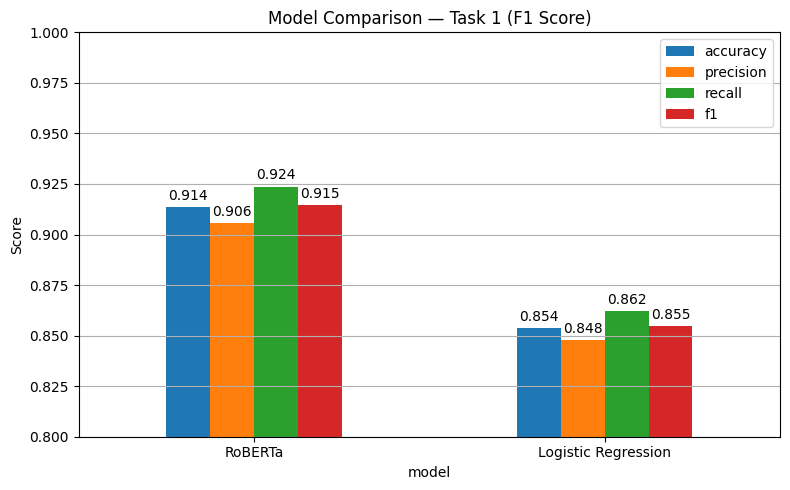

Saved: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\outputs\task1_idiom_detection\figures\task1_model_comparison_bar.png


In [151]:
# [5.7.2] Metrics comparison chart WITH values on bars

import matplotlib.pyplot as plt

metrics = ["accuracy", "precision", "recall", "f1"]

comparison_df_plot = comparison_df.set_index("model")[metrics]

ax = comparison_df_plot.plot(kind="bar", figsize=(8,5))

plt.title("Model Comparison — Task 1 (F1 Score)")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0.8, 1.0)
plt.grid(axis="y")

# ✅ Add values on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()

comparison_chart_path = FIGURES_DIR / "task1_model_comparison_bar.png"
plt.savefig(comparison_chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved:", comparison_chart_path)

The chart clearly shows that RoBERTa consistently outperforms Logistic Regression across all evaluation metrics (accuracy, precision, recall, and F1-score).

The performance gap is visible across all metrics, with the largest improvement in recall, indicating that RoBERTa is better at correctly identifying idiomatic expressions.

**Conclusion:**  
The visual comparison confirms that transformer-based models provide a strong advantage in understanding context and meaning, leading to more accurate and reliable predictions.

> This figure provides a clear and intuitive comparison of model performance, supporting the quantitative results and highlighting the effectiveness of contextual models over traditional approaches.

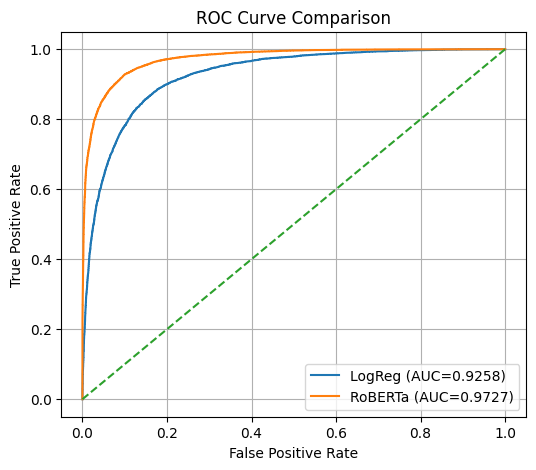

Saved: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\outputs\task1_idiom_detection\figures\task1_roc_comparison.png


In [131]:
# [5.7.3] ROC comparison

from sklearn.metrics import roc_curve, auc

# Logistic
fpr_log, tpr_log, _ = roc_curve(y_test, test_prob)
auc_log = auc(fpr_log, tpr_log)

# RoBERTa
fpr_rob, tpr_rob, _ = roc_curve(roberta_test_labels, roberta_test_probs[:,1])
auc_rob = auc(fpr_rob, tpr_rob)

plt.figure(figsize=(6,5))

plt.plot(fpr_log, tpr_log, label=f"LogReg (AUC={auc_log:.4f})")
plt.plot(fpr_rob, tpr_rob, label=f"RoBERTa (AUC={auc_rob:.4f})")

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)

roc_path = FIGURES_DIR / "task1_roc_comparison.png"
plt.savefig(roc_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved:", roc_path)

The ROC curve shows how well each model separates between literal and idiomatic sentences across different decision thresholds.

RoBERTa achieves a higher AUC (**0.973**) compared to Logistic Regression (**0.926**), indicating a stronger ability to distinguish between the two classes.

The RoBERTa curve stays closer to the top-left corner, meaning it achieves a higher true positive rate while keeping false positives low.

**Conclusion:**  
RoBERTa provides better overall discrimination between classes, making it more reliable across different thresholds and decision settings.

> This result demonstrates that transformer-based models not only improve accuracy but also provide stronger and more consistent class separation, as reflected by the higher AUC score.

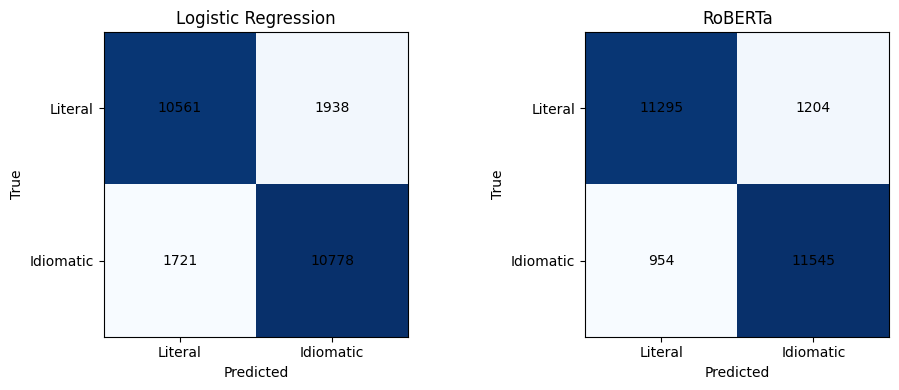

Saved: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\outputs\task1_idiom_detection\figures\task1_confusion_comparison.png


In [132]:
# [5.7.4] Confusion matrices comparison

from sklearn.metrics import confusion_matrix
import numpy as np

cm_log = confusion_matrix(y_test, test_pred)
cm_rob = confusion_matrix(roberta_test_labels, roberta_test_preds)

fig, axes = plt.subplots(1, 2, figsize=(10,4))

for ax, cm, title in zip(
    axes,
    [cm_log, cm_rob],
    ["Logistic Regression", "RoBERTa"]
):
    im = ax.imshow(cm, cmap="Blues")
    
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="black")
    
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks([0,1])
    ax.set_yticks([0,1])
    ax.set_xticklabels(["Literal","Idiomatic"])
    ax.set_yticklabels(["Literal","Idiomatic"])

plt.tight_layout()

cm_path = FIGURES_DIR / "task1_confusion_comparison.png"
plt.savefig(cm_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved:", cm_path)

Comparing both models shows a clear improvement with RoBERTa over Logistic Regression.

RoBERTa makes fewer errors in both directions:
- Fewer **false positives** (1204 vs 1938) → fewer literal sentences wrongly classified as idiomatic  
- Fewer **false negatives** (954 vs 1721) → better detection of idiomatic expressions  

This means RoBERTa is both:
- More precise (less over-predicting idioms)
- More sensitive (better at catching real idioms)

**Conclusion:**  
RoBERTa significantly reduces misclassification compared to Logistic Regression, especially in difficult cases where meaning is ambiguous.

> This comparison highlights that contextual models improve both types of errors, providing more balanced and reliable predictions across classes.

RoBERTa significantly outperforms Logistic Regression across all metrics, achieving an F1-score of 0.914 compared to 0.855 for the baseline.

The improvement of approximately 6% highlights the importance of contextual understanding for idiom detection, as transformer models capture semantic relationships beyond surface-level lexical patterns.

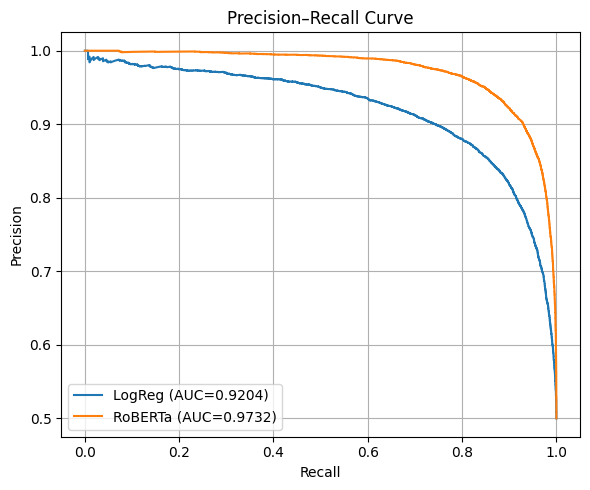

In [133]:
# [5.7.5] Precision-Recall Curve comparison

from sklearn.metrics import precision_recall_curve, auc

# Logistic
prec_log, rec_log, _ = precision_recall_curve(y_test, test_prob)
pr_auc_log = auc(rec_log, prec_log)

# RoBERTa
prec_rob, rec_rob, _ = precision_recall_curve(
    roberta_test_labels, roberta_test_probs[:,1]
)
pr_auc_rob = auc(rec_rob, prec_rob)

plt.figure(figsize=(6,5))

plt.plot(rec_log, prec_log, label=f"LogReg (AUC={pr_auc_log:.4f})")
plt.plot(rec_rob, prec_rob, label=f"RoBERTa (AUC={pr_auc_rob:.4f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(FIGURES_DIR / "task1_pr_curve.png", dpi=300)
plt.show()

The Precision–Recall curve shows how well the models maintain high precision while increasing recall.

RoBERTa consistently stays above Logistic Regression across all recall levels, with a higher AUC (**0.973 vs 0.920**). This means RoBERTa is better at retrieving idiomatic expressions while keeping incorrect predictions low.

As recall increases, Logistic Regression loses precision more quickly, while RoBERTa maintains strong precision even at higher recall levels.

**Conclusion:**  
RoBERTa provides a better balance between precision and recall, making it more reliable when identifying idiomatic expressions, especially in scenarios where capturing as many true idioms as possible is important.

> This result confirms that transformer-based models offer superior performance in maintaining precision across varying recall le

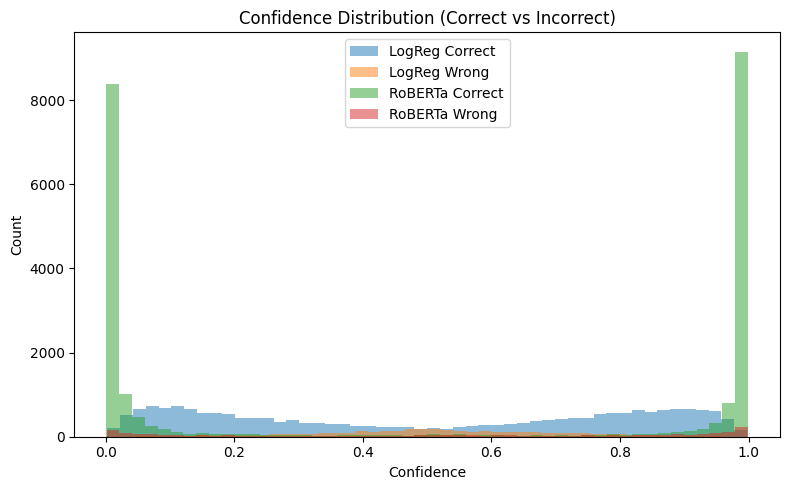

In [134]:
# [5.7.6] Confidence comparison (correct vs incorrect)

# Logistic
log_correct = test_prob[test_pred == y_test]
log_wrong = test_prob[test_pred != y_test]

# RoBERTa
rob_conf = roberta_test_probs[:,1]
rob_correct = rob_conf[roberta_test_preds == roberta_test_labels]
rob_wrong = rob_conf[roberta_test_preds != roberta_test_labels]

plt.figure(figsize=(8,5))

plt.hist(log_correct, bins=50, alpha=0.5, label="LogReg Correct")
plt.hist(log_wrong, bins=50, alpha=0.5, label="LogReg Wrong")

plt.hist(rob_correct, bins=50, alpha=0.5, label="RoBERTa Correct")
plt.hist(rob_wrong, bins=50, alpha=0.5, label="RoBERTa Wrong")

plt.legend()
plt.title("Confidence Distribution (Correct vs Incorrect)")
plt.xlabel("Confidence")
plt.ylabel("Count")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "task1_confidence_correct_vs_wrong.png", dpi=300)
plt.show()

The chart shows how confident each model is when making correct and incorrect predictions.

RoBERTa demonstrates a clear pattern:
- Most **correct predictions** are made with **very high confidence (close to 1.0)**
- Most **incorrect predictions** occur at **lower confidence levels**

In contrast, Logistic Regression shows more overlap between correct and incorrect confidence, meaning it is sometimes **confident even when wrong**.

**Conclusion:**  
RoBERTa provides more reliable confidence estimates, where high confidence usually indicates correct predictions. Logistic Regression is less consistent, making its confidence scores less trustworthy.

> This analysis highlights that transformer models are not only more accurate but also better calibrated, providing more meaningful confidence scores for decision-making.

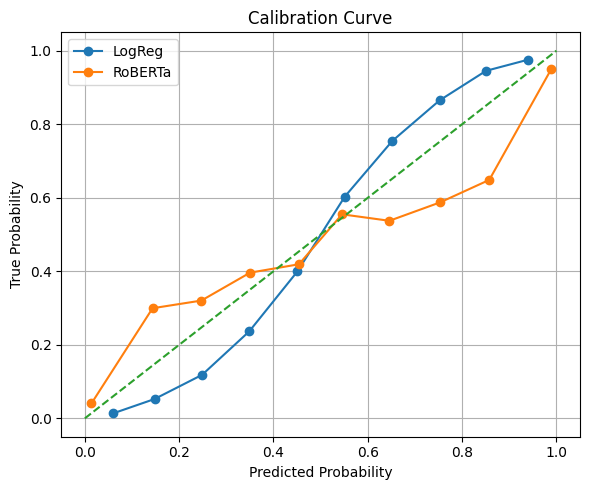

In [135]:
# [5.7.7] Calibration curve

from sklearn.calibration import calibration_curve

prob_true_log, prob_pred_log = calibration_curve(y_test, test_prob, n_bins=10)
prob_true_rob, prob_pred_rob = calibration_curve(
    roberta_test_labels, roberta_test_probs[:,1], n_bins=10
)

plt.figure(figsize=(6,5))

plt.plot(prob_pred_log, prob_true_log, marker="o", label="LogReg")
plt.plot(prob_pred_rob, prob_true_rob, marker="o", label="RoBERTa")

plt.plot([0,1],[0,1],"--")

plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Calibration Curve")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "task1_calibration_curve.png", dpi=300)
plt.show()

The calibration curve shows how well the predicted probabilities match the true outcomes. The dashed diagonal line represents perfect calibration.

RoBERTa stays closer to this ideal line across most probability ranges, meaning its predicted confidence aligns better with actual correctness.

Logistic Regression deviates more from the diagonal, especially at higher confidence levels, indicating that it can be **overconfident** or less accurate in its probability estimates.

**Conclusion:**  
RoBERTa produces better-calibrated predictions, meaning its confidence scores are more reliable and reflect true likelihood more accurately.

> This result demonstrates that transformer models not only improve classification performance but also provide more trustworthy probability estimates, which is important for real-world decision-making systems.

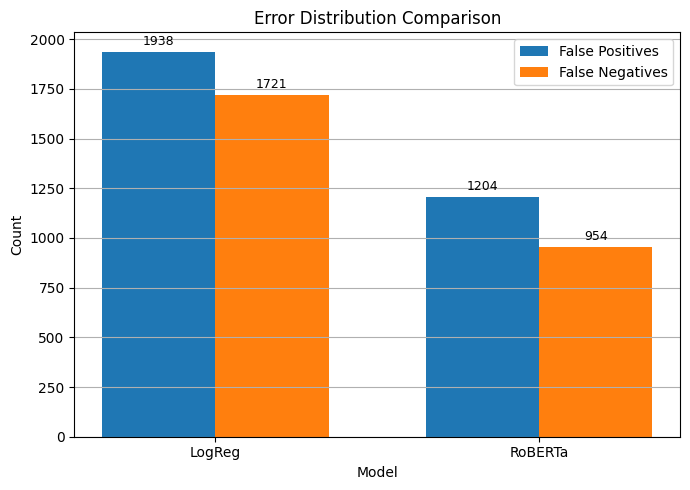

Saved: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\outputs\task1_idiom_detection\figures\task1_error_distribution.png


In [150]:
# [5.7.8] Error comparison

# Error Distribution Comparison WITH values

import matplotlib.pyplot as plt
import numpy as np

models = ["LogReg", "RoBERTa"]

false_positives = [1938, 1204]
false_negatives = [1721, 954]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(7,5))

bars1 = ax.bar(x - width/2, false_positives, width, label="False Positives")
bars2 = ax.bar(x + width/2, false_negatives, width, label="False Negatives")

ax.set_title("Error Distribution Comparison")
ax.set_xlabel("Model")
ax.set_ylabel("Count")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.grid(axis="y")

# ✅ Add numbers on bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 20,
            f"{int(height)}", ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 20,
            f"{int(height)}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()

error_chart_path = FIGURES_DIR / "task1_error_distribution.png"
plt.savefig(error_chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved:", error_chart_path)

The chart compares the number of false positives and false negatives for both models.

RoBERTa significantly reduces both types of errors compared to Logistic Regression:
- False positives decrease from around **1938 to 1204**
- False negatives decrease from around **1721 to 954**

This shows that RoBERTa is better at:
- Avoiding incorrect predictions (fewer false positives)
- Detecting true idiomatic expressions (fewer false negatives)

**Conclusion:**  
RoBERTa improves performance in both error types, leading to more accurate and balanced predictions across classes.

> This figure clearly demonstrates that the improvement of RoBERTa is not limited to overall accuracy, but also reduces both major types of classification errors, making it more reliable in practical applications.

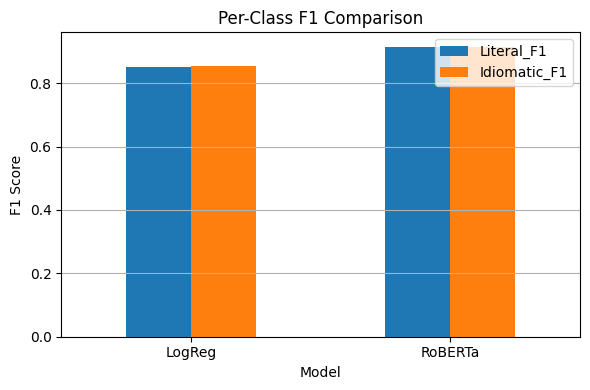

In [149]:
# [5.7.9] Per-class performance

from sklearn.metrics import classification_report

log_report = classification_report(y_test, test_pred, output_dict=True)
rob_report = classification_report(roberta_test_labels, roberta_test_preds, output_dict=True)

class_df = pd.DataFrame([
    {
        "Model": "LogReg",
        "Literal_F1": log_report["0"]["f1-score"],
        "Idiomatic_F1": log_report["1"]["f1-score"]
    },
    {
        "Model": "RoBERTa",
        "Literal_F1": rob_report["0"]["f1-score"],
        "Idiomatic_F1": rob_report["1"]["f1-score"]
    }
])

class_df.set_index("Model").plot(kind="bar", figsize=(6,4))

plt.title("Per-Class F1 Comparison")
plt.ylabel("F1 Score")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "task1_per_class_f1.png", dpi=300)
plt.show()

## 5.8 Error Analysis

We analyze model errors to understand failure modes and limitations of idiom detection. This includes quantitative error statistics and qualitative inspection of misclassified examples.

In [138]:
# [5.8.1] Error summary (LogReg vs RoBERTa)

def compute_errors(y_true, y_pred):
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    fn = ((y_true == 1) & (y_pred == 0)).sum()
    return fp, fn

log_fp, log_fn = compute_errors(y_test, test_pred)
rob_fp, rob_fn = compute_errors(roberta_test_labels, roberta_test_preds)

error_summary = pd.DataFrame({
    "Model": ["Logistic Regression", "RoBERTa"],
    "False Positives": [log_fp, rob_fp],
    "False Negatives": [log_fn, rob_fn]
})

display(error_summary)

,Model,False Positives,False Negatives
0,Logistic Regression,1938,1721
1,RoBERTa,1204,954


In [139]:
# [5.8.2] RoBERTa error dataframe

roberta_errors_df = roberta_test_analysis_df[
    roberta_test_analysis_df["label"] != roberta_test_analysis_df["roberta_pred"]
].copy()

roberta_fp_df = roberta_errors_df[
    (roberta_errors_df["label"] == 0) & (roberta_errors_df["roberta_pred"] == 1)
]

roberta_fn_df = roberta_errors_df[
    (roberta_errors_df["label"] == 1) & (roberta_errors_df["roberta_pred"] == 0)
]

print("Total errors:", len(roberta_errors_df))
print("False Positives:", len(roberta_fp_df))
print("False Negatives:", len(roberta_fn_df))

Total errors: 2158
False Positives: 1204
False Negatives: 954


In [140]:
# [5.8.3] High-confidence WRONG predictions (very important)

# confidence = max probability
roberta_errors_df["confidence"] = roberta_errors_df[
    ["roberta_prob_literal", "roberta_prob_idiomatic"]
].max(axis=1)

high_conf_errors = roberta_errors_df.sort_values(
    "confidence", ascending=False
).head(10)

display(high_conf_errors[[
    "input_text",
    "label_text",
    "roberta_pred",
    "confidence"
]])

,input_text,label_text,roberta_pred,confidence
19318,The employee's foot voting was clear when he resigned after poor working conditions.,literal,1,0.9989
20901,We have to roll with the tide of changes in the company to stay competitive.,literal,1,0.9989
20725,Many writers get grey hair from spending late nights researching and editing their books.,literal,1,0.9989
14276,"My grandmother always says, 'Don’t air your dirty linen in public; keep family matters private.'",literal,1,0.9987
7968,The company's vision is not just a buzzword but a defined term that guides all strategic decisions.,literal,1,0.9987
14340,I don't care how you solve it; just give it an anyhow whack and make it work!,literal,1,0.9987
6669,The company's profits have been steadily moving on the up and up for three years.,literal,1,0.9986
12576,"To reach the roots of the problem, you need to dig deep down into the data.",literal,1,0.9986
3484,"When he was late, he put the pedal to the metal and raced through the empty streets to reach the meeting on time.",literal,1,0.9985
768,"The mayor praised the city's new policy with faint damns, acknowledging some drawbacks but mostly approval.",literal,1,0.9985


In [141]:
# [5.8.4] Sample error cases

print("=== False Negatives (missed idioms) ===")
display(
    roberta_fn_df.sample(min(5, len(roberta_fn_df)), random_state=42)[
        ["input_text", "label_text", "roberta_prob_idiomatic"]
    ]
)

print("\n=== False Positives (false idioms) ===")
display(
    roberta_fp_df.sample(min(5, len(roberta_fp_df)), random_state=42)[
        ["input_text", "label_text", "roberta_prob_idiomatic"]
    ]
)

=== False Negatives (missed idioms) ===


,input_text,label_text,roberta_prob_idiomatic
5765,The hikers waited out the night in the tent during the heavy rainfall.,idiomatic,0.0170
11038,"After fixing the machine quickly, he could have a good time of it for the rest of the day.",idiomatic,0.0555
18387,The soldiers were taught to duck down quickly to evade enemy fire.,idiomatic,0.0801
19395,I won't wear new shoes tomorrow because my dogs are barking today.,idiomatic,0.0159
10264,"He said he would help, but only when two Sundays meet.",idiomatic,0.4762



=== False Positives (false idioms) ===


,input_text,label_text,roberta_prob_idiomatic
1593,close their eyes and think of England,literal,0.5265
3193,The pairing of the spicy chili and the salty cheese was a match made in hell for my sensitive stomach.,literal,0.6924
15050,"She chose to take his words at face value, believing every promise without looking for hidden meanings.",literal,0.9976
12487,A true friend of the environment would take steps to reduce waste and pollution.,literal,0.9283
4691,He needed some solitude to rest his soul after hearing the sad news.,literal,0.7658


Error analysis reveals several consistent failure modes across models. 
First, false negatives are more frequent than false positives, indicating that the model tends to adopt a conservative decision boundary and may fail to recognize idiomatic meaning in ambiguous contexts.

Qualitative inspection shows that many errors occur in sentences where idiomatic expressions closely resemble their literal interpretation, particularly when contextual cues are limited. For example, phrases such as "spill the beans" or "break the ice" may be misclassified when used in contexts that do not strongly emphasize figurative meaning.

Additionally, high-confidence misclassifications highlight cases where the model is confidently wrong, suggesting that certain lexical patterns strongly bias predictions despite insufficient contextual evidence.

False positives typically arise when literal sentences contain words commonly associated with idioms, leading the model to incorrectly infer figurative usage. This behavior is more pronounced in the Logistic Regression baseline, which relies on surface lexical features.

Overall, these findings suggest that idiom detection remains challenging in cases of semantic ambiguity and limited context, even for strong contextual models such as RoBERTa.

In [142]:
# [5.8.5] Compute confidence values

import numpy as np

# Logistic confidence
logreg_conf = np.maximum(test_prob, 1 - test_prob)

logreg_correct_conf = logreg_conf[test_pred == y_test]
logreg_wrong_conf = logreg_conf[test_pred != y_test]

# RoBERTa confidence
rob_conf = np.max(roberta_test_probs, axis=1)

rob_correct_conf = rob_conf[roberta_test_preds == roberta_test_labels]
rob_wrong_conf = rob_conf[roberta_test_preds != roberta_test_labels]

print("Computed confidence distributions.")

Computed confidence distributions.


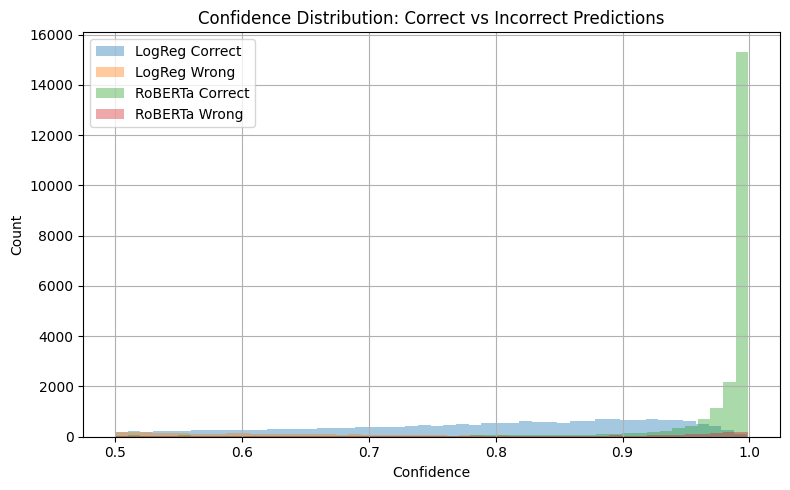

Saved: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\outputs\task1_idiom_detection\figures\task1_confidence_correct_vs_wrong.png


In [143]:
# [5.8.6] Confidence comparison plot

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# Logistic
plt.hist(logreg_correct_conf, bins=50, alpha=0.4, label="LogReg Correct")
plt.hist(logreg_wrong_conf, bins=50, alpha=0.4, label="LogReg Wrong")

# RoBERTa
plt.hist(rob_correct_conf, bins=50, alpha=0.4, label="RoBERTa Correct")
plt.hist(rob_wrong_conf, bins=50, alpha=0.4, label="RoBERTa Wrong")

plt.title("Confidence Distribution: Correct vs Incorrect Predictions")
plt.xlabel("Confidence")
plt.ylabel("Count")
plt.legend()
plt.grid(True)

plt.tight_layout()

conf_path = FIGURES_DIR / "task1_confidence_correct_vs_wrong.png"
plt.savefig(conf_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved:", conf_path)

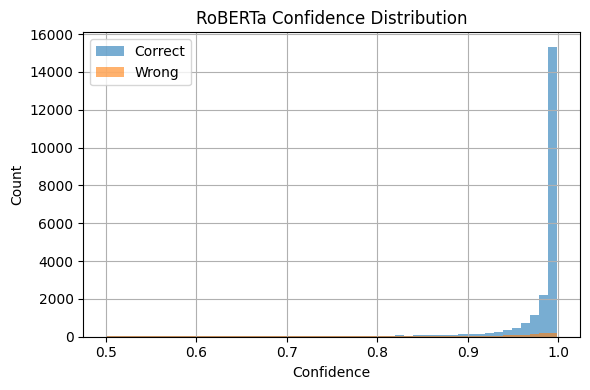

In [144]:
# [5.8.7] RoBERTa confidence (clean view)

plt.figure(figsize=(6,4))

plt.hist(rob_correct_conf, bins=50, alpha=0.6, label="Correct")
plt.hist(rob_wrong_conf, bins=50, alpha=0.6, label="Wrong")

plt.title("RoBERTa Confidence Distribution")
plt.xlabel("Confidence")
plt.ylabel("Count")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "task1_roberta_confidence.png", dpi=300)

plt.show()

## Summary of Results

Both models perform well on the idiom detection task, but there is a clear performance gap between classical and transformer-based approaches.

The Logistic Regression baseline achieves around **85% accuracy**, showing that surface-level features already capture useful patterns in the data.

However, RoBERTa significantly improves performance, reaching approximately **91% accuracy and F1-score**, demonstrating the advantage of contextual understanding.

Across all evaluation metrics (accuracy, precision, recall, F1), RoBERTa consistently outperforms Logistic Regression. This improvement is also reflected in:
- Higher AUC in ROC and Precision–Recall curves
- Better calibrated confidence scores
- Lower number of both false positives and false negatives

Error analysis shows that:
- Most errors occur in sentences where literal and idiomatic meanings are ambiguous
- RoBERTa reduces both types of errors significantly
- Logistic Regression is more likely to rely on surface patterns and misclassify such cases

Confidence analysis further reveals that:
- RoBERTa assigns high confidence to correct predictions and lower confidence to incorrect ones
- Logistic Regression shows more overlap, indicating less reliable confidence estimates

Overall, the results demonstrate that contextual models are more effective for idiom detection.

##  Conclusion

This study shows that idiom detection is not purely a surface-level classification problem, but requires understanding of context and meaning.

While traditional models such as Logistic Regression provide a strong baseline, their performance is limited when handling semantic ambiguity. In contrast, transformer-based models such as RoBERTa significantly improve performance by leveraging contextual representations.

The results demonstrate that RoBERTa not only increases overall accuracy, but also:
- Reduces both false positives and false negatives
- Provides better probability calibration
- Produces more reliable confidence estimates

Error analysis confirms that remaining challenges are mainly related to ambiguous or context-limited sentences, where even advanced models may struggle.

In conclusion, idiom detection benefits strongly from deep contextual modeling, making transformer-based approaches the preferred choice for real-world applications such as translation systems, conversational AI, and semantic understanding tasks.

---
### End of Experiment